# Exploratory Data Analysis, Home Credit Default Risk

**Project:** Knowledge Discovery in Banking Dataset
**Phase:** 1, Data Understanding & Preprocessing
**Step:** 1, EDA & Analytical Justification
**Dataset:** Home Credit Default Risk (Kaggle)

---

Everything downstream rests on this notebook. Before we clean or transform anything, we need to understand what the data actually is: how the tables fit together, where values go missing and why, which numbers are real extremes versus data-entry mistakes, and what each quirk means in a banking context.

So this is a diagnosis, not a treatment. We do not change a single value here. We read the data closely, write down what we find, and turn each finding into a specific, justified decision for the preprocessing pipeline in Step 2. If a choice in Step 2 looks surprising, it should be traceable back to a paragraph in this notebook.

## Setup, Libraries and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.4f}'.format)

In [2]:
DATA = '../datasets/'

app        = pd.read_csv(DATA + 'application_train.csv')
bureau     = pd.read_csv(DATA + 'bureau.csv')
bureau_bal = pd.read_csv(DATA + 'bureau_balance.csv')
prev       = pd.read_csv(DATA + 'previous_application.csv')
pos        = pd.read_csv(DATA + 'POS_CASH_balance.csv')
inst       = pd.read_csv(DATA + 'installments_payments.csv')
cc         = pd.read_csv(DATA + 'credit_card_balance.csv')

print('All datasets loaded successfully.')
print(f'  application_train : {app.shape[0]:>8,} rows x {app.shape[1]:>3} cols')
print(f'  bureau            : {bureau.shape[0]:>8,} rows x {bureau.shape[1]:>3} cols')
print(f'  bureau_balance    : {bureau_bal.shape[0]:>8,} rows x {bureau_bal.shape[1]:>3} cols')
print(f'  previous_app      : {prev.shape[0]:>8,} rows x {prev.shape[1]:>3} cols')
print(f'  POS_CASH_balance  : {pos.shape[0]:>8,} rows x {pos.shape[1]:>3} cols')
print(f'  installments      : {inst.shape[0]:>8,} rows x {inst.shape[1]:>3} cols')
print(f'  credit_card_bal   : {cc.shape[0]:>8,} rows x {cc.shape[1]:>3} cols')

All datasets loaded successfully.
  application_train :  307,511 rows x 122 cols
  bureau            : 1,716,428 rows x  17 cols
  bureau_balance    : 27,299,925 rows x   3 cols
  previous_app      : 1,670,214 rows x  37 cols
  POS_CASH_balance  : 10,001,358 rows x   8 cols
  installments      : 13,605,401 rows x   8 cols
  credit_card_bal   : 3,840,312 rows x  23 cols


---
## Section 1: Dataset Orientation

### What we are checking, and why

Before looking at any single feature, we need to know what each table holds, what one row actually represents (its grain), and how the tables connect. Get the grain wrong and every later aggregation inflates or double-counts. That mistake silently propagates into clustering and rule mining, so it is worth a few minutes up front.

The dataset is a star schema with `application_train.csv` at the centre. Each related table describes a different slice of the applicant's financial life. We look at four things: how big and how structured each table is, whether the main table has duplicate applications, how many related records a typical applicant has, and which applicants show up in which tables.

In [3]:
print('=== application_train.csv ===')
print(f'Rows: {len(app):,}  |  Columns: {app.shape[1]}')
print(f'Dtype breakdown: {dict(app.dtypes.value_counts())}')

n_unique_pk = app['SK_ID_CURR'].nunique()
print(f'\nPrimary key (SK_ID_CURR) uniqueness: {n_unique_pk:,} unique of {len(app):,} total')
print(f'Duplicate PKs: {len(app) - n_unique_pk}')

num_cols = app.select_dtypes(include=np.number).columns.difference(['SK_ID_CURR','TARGET'])
cat_cols = app.select_dtypes(include='object').columns
print(f'\nNumerical features : {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')

print('\n=== Relational Table Summary ===')
n_app = app['SK_ID_CURR'].nunique()
tables = [('bureau', bureau), ('previous_application', prev),
          ('POS_CASH_balance', pos), ('installments_payments', inst),
          ('credit_card_balance', cc)]
print(f"{'Table':<28} {'Rows':>10} {'Applicants':>12} {'Missing':>10}")
print('-' * 65)
for name, df in tables:
    if 'SK_ID_CURR' in df.columns:
        n_linked = df['SK_ID_CURR'].nunique()
        n_miss = n_app - n_linked
        print(f'{name:<28} {len(df):>10,} {n_linked:>12,} {n_miss:>10,}')

print('\n=== Records-per-applicant Distribution ===')
for name, df in tables:
    if 'SK_ID_CURR' not in df.columns:
        continue
    c = df['SK_ID_CURR'].value_counts()
    print(f'{name:<28}  med={c.median():.0f}  p75={c.quantile(0.75):.0f}  p95={c.quantile(0.95):.0f}  max={c.max()}')

=== application_train.csv ===
Rows: 307,511  |  Columns: 122
Dtype breakdown: {dtype('float64'): np.int64(65), dtype('int64'): np.int64(41), <StringDtype(na_value=nan)>: np.int64(16)}

Primary key (SK_ID_CURR) uniqueness: 307,511 unique of 307,511 total
Duplicate PKs: 0

Numerical features : 104
Categorical features: 16

=== Relational Table Summary ===
Table                              Rows   Applicants    Missing
-----------------------------------------------------------------
bureau                        1,716,428      305,811      1,700


previous_application          1,670,214      338,857    -31,346


POS_CASH_balance             10,001,358      337,252    -29,741


installments_payments        13,605,401      339,587    -32,076
credit_card_balance           3,840,312      103,558    203,953

=== Records-per-applicant Distribution ===


bureau                        med=4  p75=8  p95=14  max=116
previous_application          med=4  p75=7  p95=13  max=77


POS_CASH_balance              med=22  p75=39  p95=80  max=295


installments_payments         med=25  p75=51  p95=131  max=372


credit_card_balance           med=22  p75=75  p95=96  max=192


### What we found

**One row, one application.** Each row of `application_train.csv` is a single loan application from one applicant. The key `SK_ID_CURR` has no duplicates across all 307,511 rows, so the main table is clean at the source.

**The 122 columns are fewer than they look.** Of the 122 columns, 106 are numeric and 16 categorical (plus `TARGET` and `SK_ID_CURR`). But roughly 48 of them are building and property measurements reported three ways each (`_AVG`, `_MODE`, `_MEDI`), so the real variety is much lower than the column count suggests. That triplication matters later for both missingness and correlation.

**How much behavioural history each applicant carries:**

| Table | Behavioural dimension | Median records/applicant | Applicants with none |
|---|---|---|---|
| `bureau` | External credit history | 4 | 1,700 (0.6%) |
| `previous_application` | Past applications | 4 |, |
| `POS_CASH_balance` | POS/cash repayment | 22 months | ~323 |
| `installments_payments` | Installment repayment | 25 records | ~323 |
| `credit_card_balance` | Revolving credit use | 22 months | ~132 |

A few structural facts shape the rest of the work. Bureau coverage is near-universal at 99.4%, so the 0.6% with no bureau record are a genuinely different group, probably first-time borrowers we cannot describe with credit-history metrics. The monthly snapshot tables are enormous (`bureau_balance` alone is 27.3M rows), so they have to be aggregated to one-row-per-applicant before any join. The median of 4 bureau records sits against a maximum of 116, so the distribution is long-tailed. And `bureau_balance` links through `SK_ID_BUREAU`, not `SK_ID_CURR`, which means a two-step join to reach applicant level.

---
## Section 2: The target label

### What we are checking, and why

`TARGET` records whether an applicant ran into payment difficulty on their Home Credit loan. We need its distribution before we can read any other feature, because how rare default is tells us how much signal to expect and how to phrase cluster-level risk later.

One ground rule: we use `TARGET` here only to understand the data and to rank feature relevance. It never enters a clustering, rule-mining, or anomaly-detection algorithm. That exclusion is written down again in the Preprocessing Report so there is no ambiguity.

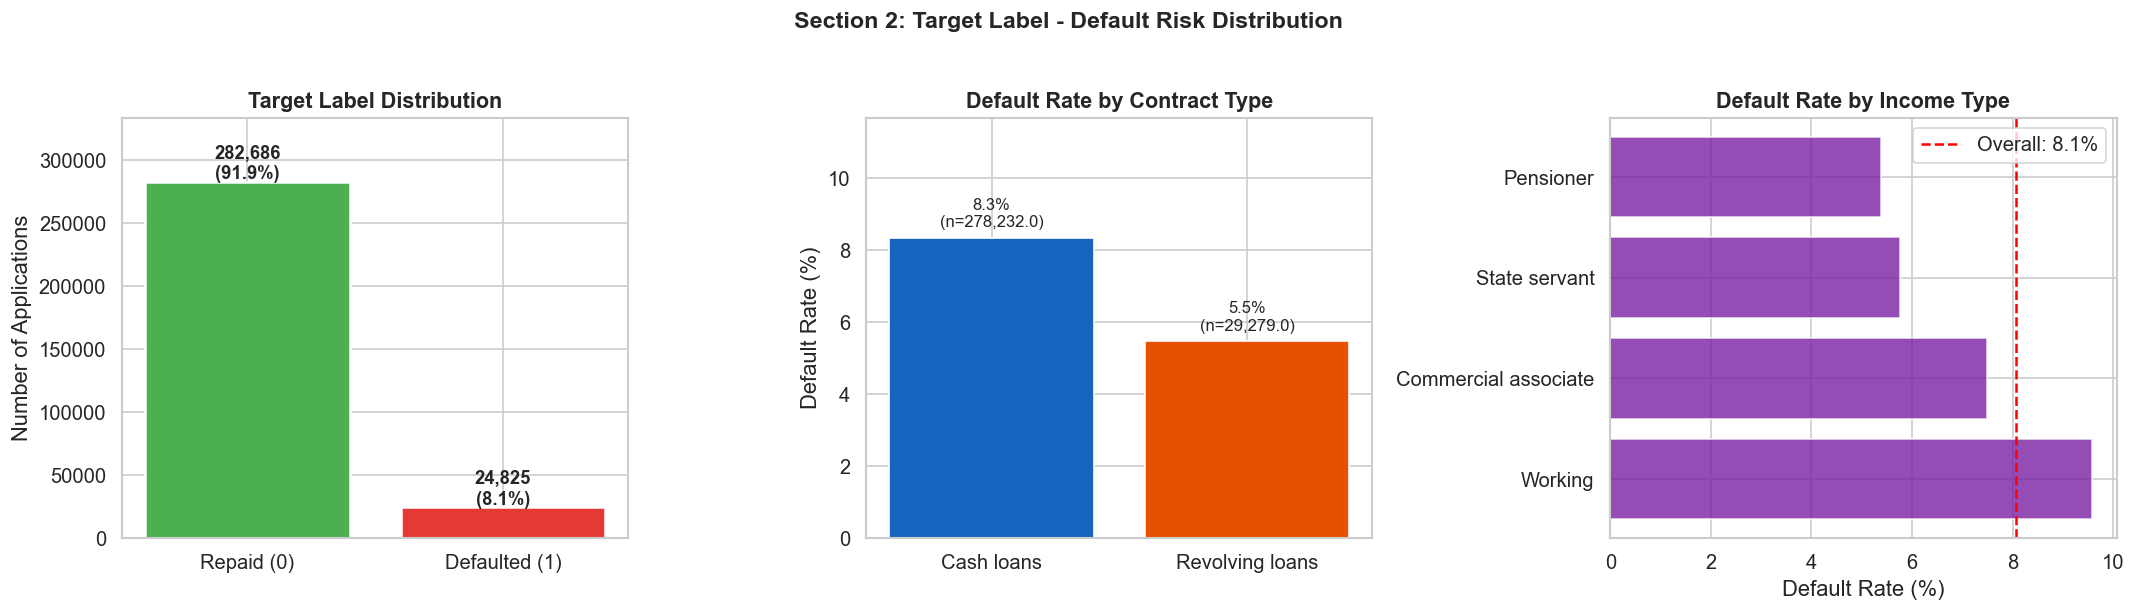

Total applications  : 307,511
Repaid  (TARGET=0) : 282,686  (91.93%)
Default (TARGET=1) : 24,825  (8.07%)
Imbalance ratio     : 11.4 : 1

Default rate by gender:


              mean   count
CODE_GENDER               
F             7.0%  202448
M            10.1%  105059


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class distribution
ax = axes[0]
vc = app['TARGET'].value_counts().sort_index()
colors = ['#4CAF50', '#E53935']
bars = ax.bar(['Repaid (0)', 'Defaulted (1)'], vc.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'{val:,}\n({val/len(app)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Target Label Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Applications')
ax.set_ylim(0, vc.max() * 1.18)

# Default rate by contract type
ax = axes[1]
ct_def = app.groupby('NAME_CONTRACT_TYPE')['TARGET'].agg(['mean','count'])
bars = ax.bar(ct_def.index, ct_def['mean'] * 100, color=['#1565C0','#E65100'], edgecolor='white')
for bar, (idx, row) in zip(bars, ct_def.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{row["mean"]*100:.1f}%\n(n={row["count"]:,})', ha='center', fontsize=10)
ax.set_title('Default Rate by Contract Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Default Rate (%)')
ax.set_ylim(0, ct_def['mean'].max() * 100 * 1.4)

# Default rate by income type
ax = axes[2]
inc_counts = app['NAME_INCOME_TYPE'].value_counts()
inc_def = app[app['NAME_INCOME_TYPE'].isin(inc_counts[inc_counts >= 50].index)] \
            .groupby('NAME_INCOME_TYPE')['TARGET'].mean().sort_values(ascending=False)
bars = ax.barh(inc_def.index, inc_def.values * 100, color='#7B1FA2', alpha=0.8)
ax.axvline(app['TARGET'].mean() * 100, color='red', linestyle='--', linewidth=1.5,
           label=f'Overall: {app["TARGET"].mean()*100:.1f}%')
ax.set_xlabel('Default Rate (%)')
ax.set_title('Default Rate by Income Type', fontsize=13, fontweight='bold')
ax.legend()

plt.suptitle('Section 2: Target Label - Default Risk Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Total applications  : {len(app):,}')
print(f'Repaid  (TARGET=0) : {(app["TARGET"]==0).sum():,}  ({(app["TARGET"]==0).mean()*100:.2f}%)')
print(f'Default (TARGET=1) : {(app["TARGET"]==1).sum():,}  ({(app["TARGET"]==1).mean()*100:.2f}%)')
print(f'Imbalance ratio     : {(app["TARGET"]==0).sum()/(app["TARGET"]==1).sum():.1f} : 1')
print('\nDefault rate by gender:')
print(app[app['CODE_GENDER']!='XNA'].groupby('CODE_GENDER')['TARGET']
        .agg(['mean','count']).assign(mean=lambda x: x['mean'].map('{:.1%}'.format)))

### What we found

**What a default means here.** `TARGET = 1` means the applicant had real payment trouble: late payments past a set number of days on at least one installment in the first repayment window.

**Default is rare.** The split is 91.9% repaid to 8.1% defaulted, about 11.4 to 1. That is normal for consumer credit, where default is uncommon but expensive. For an unsupervised project it has a practical consequence: every cluster will be mostly non-defaulters by headcount, so cluster risk only means something as a *rate*, never as a raw count.

**Risk is not spread evenly:**

- Cash loans default at 8.3%, revolving loans at 5.5%. Revolving customers look better screened or more financially settled, which is the opposite of what we would expect in some other markets.
- Men default at 10.1%, women at 7.0%. A 44% relative gap is large, and probably reflects both who borrows and what they borrow for.
- Working applicants default at 9.6%, well above pensioners (5.4%) and state servants (5.8%). A pension is fixed and predictable income, which cushions against default; salaried workers carry more income volatility.

So the label is understood and its distribution mapped. From here it feeds only the feature-relevance ranking in Section 7, and it is dropped from every feature matrix handed to the mining algorithms.

---
## Section 3: Missing values

### What we are checking, and why

In banking data a blank is rarely just a blank. A missing `OWN_CAR_AGE` almost always means the applicant has no car. A missing `EXT_SOURCE_1` often means the credit bureau could not score them, which is itself a sign of a thin credit file. So for every column with real missingness we ask the same question: why is this absent, and what does the absence say about this person?

We sort columns into four bands by how much is missing: under 5% (likely a collection gap, safe to fill), 5 to 30% (worth investigating, may be conditional), 30 to 60% (often structurally absent, where filling just manufactures noise), and over 60% (barely usable as a number, better captured by a yes/no "was it missing" flag).

Missingness tier summary:
  Tier 1 (<5%): 10 columns
  Tier 2 (5-30%): 7 columns
  Tier 3 (30-60%): 33 columns
  Tier 4 (>60%): 17 columns
  No missing: 55 columns


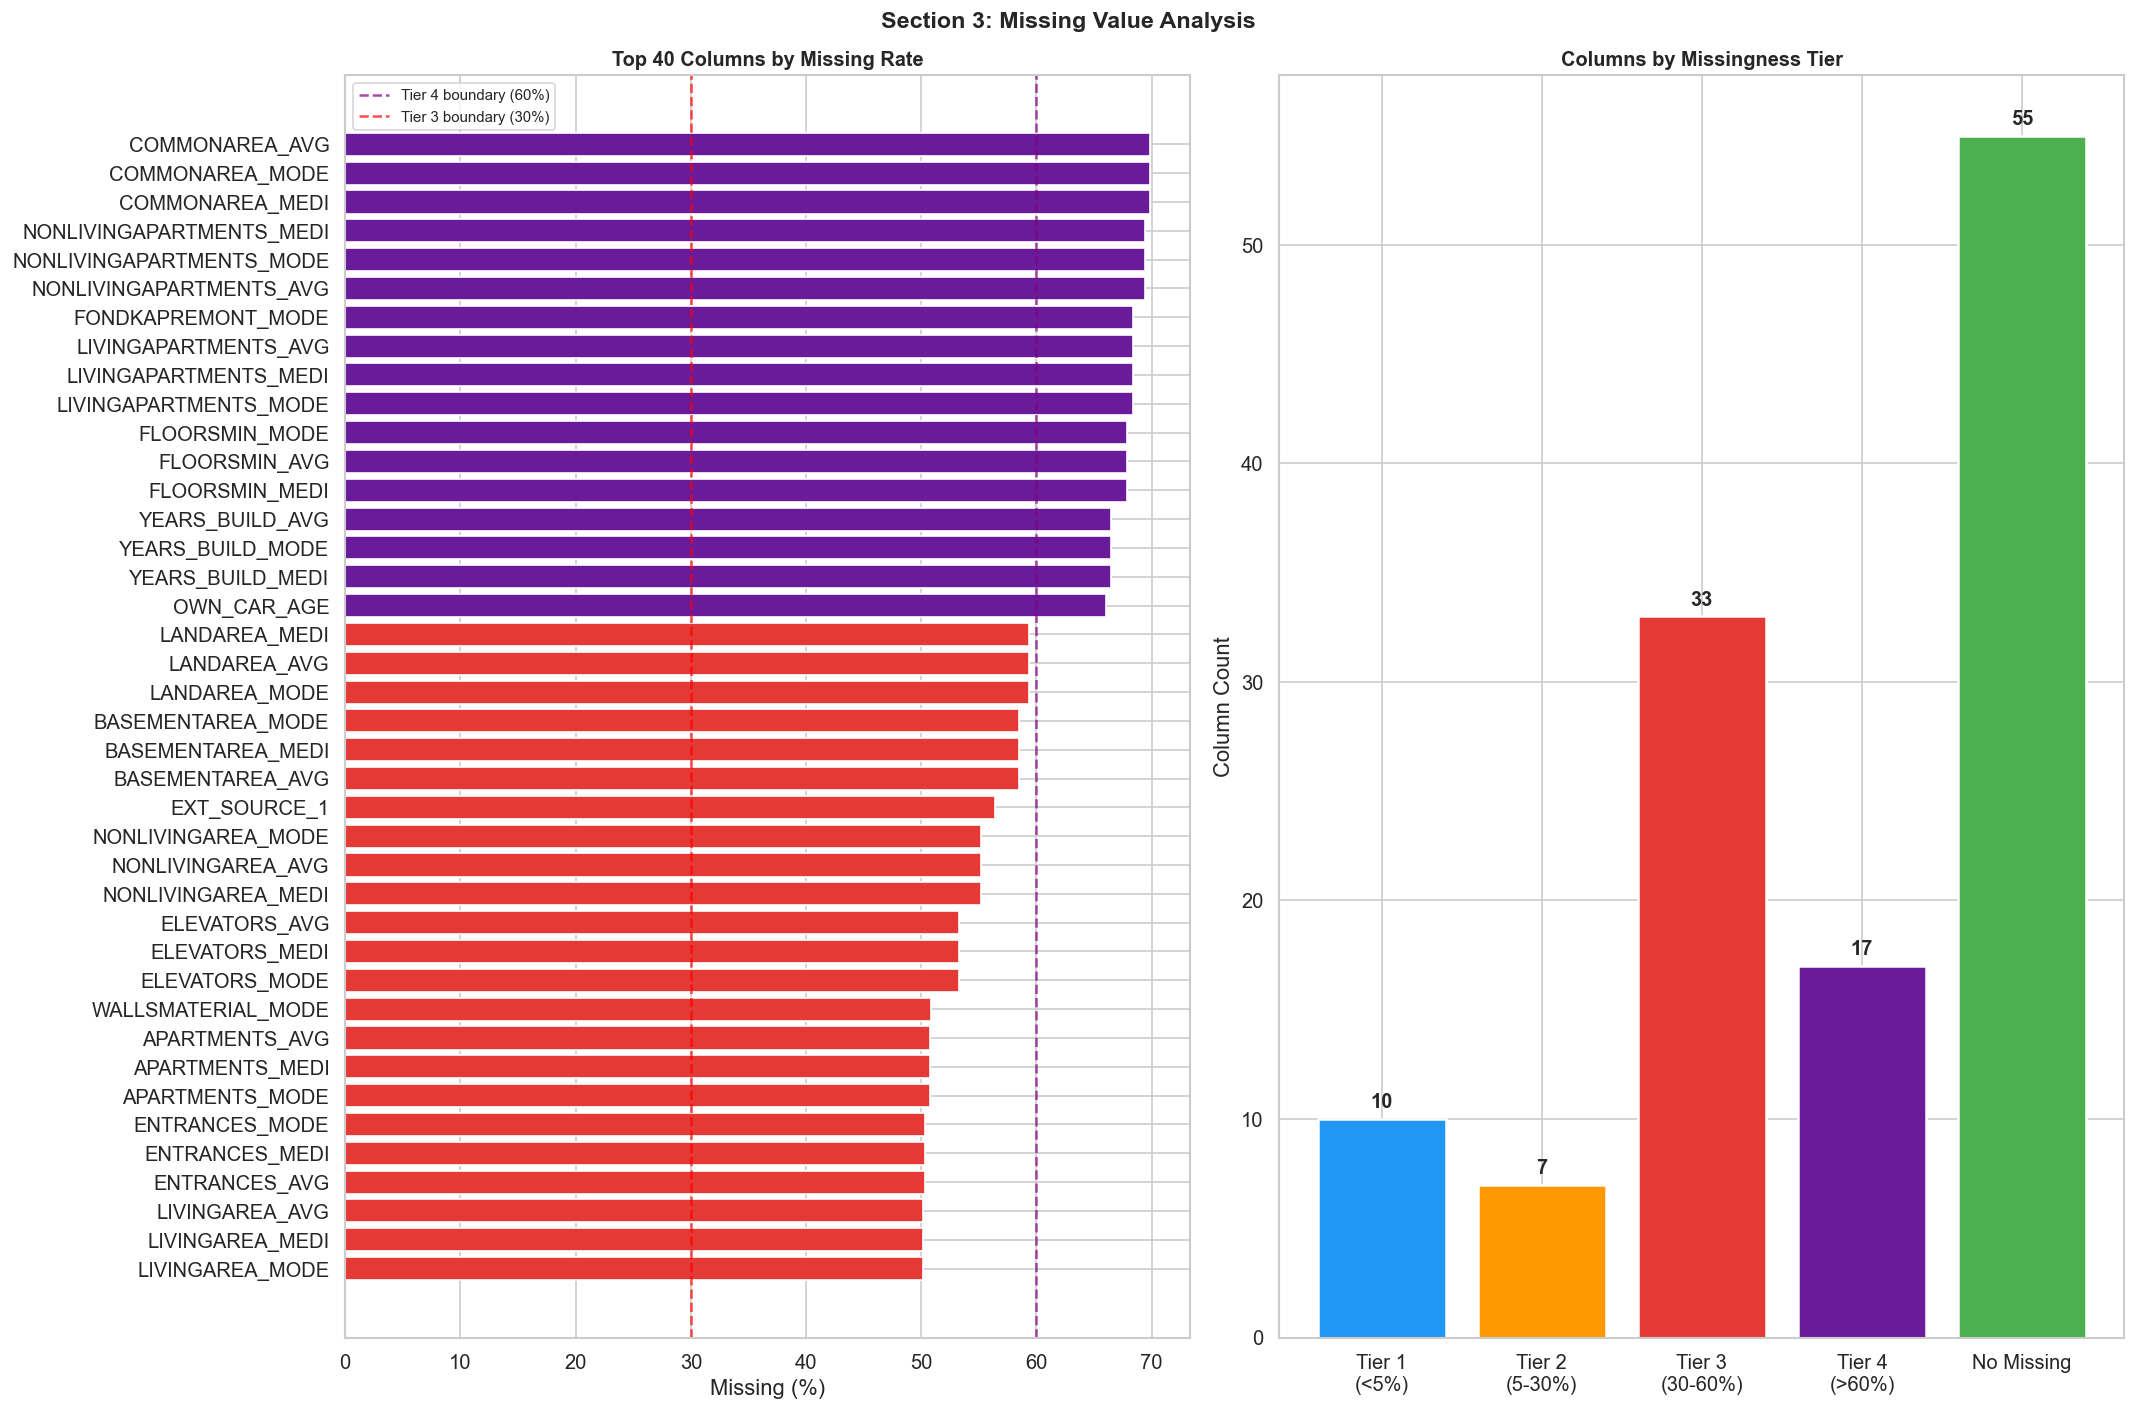


--- Key domain columns ---
  EXT_SOURCE_1                       : 56.38%
  EXT_SOURCE_2                       : 0.21%
  EXT_SOURCE_3                       : 19.83%
  OWN_CAR_AGE                        : 65.99%
  OCCUPATION_TYPE                    : 31.35%
  AMT_ANNUITY                        : 0.00%
  AMT_GOODS_PRICE                    : 0.09%

Housing-related columns (47 total): range 47.4%-69.9%


In [5]:
missing_counts = app.isnull().sum()
missing_pct    = (missing_counts / len(app) * 100).round(2)
missing_df = pd.DataFrame({'count': missing_counts, 'pct': missing_pct}) \
               .sort_values('pct', ascending=False)
missing_df = missing_df[missing_df['count'] > 0]

def tier(pct):
    if pct < 5:  return 'Tier 1 (<5%)'
    if pct < 30: return 'Tier 2 (5-30%)'
    if pct < 60: return 'Tier 3 (30-60%)'
    return              'Tier 4 (>60%)'

missing_df['tier'] = missing_df['pct'].apply(tier)
tier_counts = missing_df['tier'].value_counts()
print('Missingness tier summary:')
for t in ['Tier 1 (<5%)', 'Tier 2 (5-30%)', 'Tier 3 (30-60%)', 'Tier 4 (>60%)', 'No missing']:
    if t == 'No missing':
        print(f'  {t}: {app.shape[1] - len(missing_df)} columns')
    else:
        print(f'  {t}: {tier_counts.get(t, 0)} columns')

tier_colors = {'Tier 1 (<5%)': '#2196F3', 'Tier 2 (5-30%)': '#FF9800',
               'Tier 3 (30-60%)': '#E53935', 'Tier 4 (>60%)': '#6A1B9A'}

fig, axes = plt.subplots(1, 2, figsize=(18, 12))

top_miss = missing_df.head(40)
colors = [tier_colors[t] for t in top_miss['tier']]
ax = axes[0]
ax.barh(top_miss.index[::-1], top_miss['pct'][::-1], color=colors[::-1])
ax.axvline(60, color='purple', linestyle='--', alpha=0.7, label='Tier 4 boundary (60%)')
ax.axvline(30, color='red',    linestyle='--', alpha=0.7, label='Tier 3 boundary (30%)')
ax.set_xlabel('Missing (%)')
ax.set_title('Top 40 Columns by Missing Rate', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
tier_labels = ['Tier 1\n(<5%)', 'Tier 2\n(5-30%)', 'Tier 3\n(30-60%)', 'Tier 4\n(>60%)', 'No Missing']
tier_vals   = [tier_counts.get('Tier 1 (<5%)', 0), tier_counts.get('Tier 2 (5-30%)', 0),
               tier_counts.get('Tier 3 (30-60%)', 0), tier_counts.get('Tier 4 (>60%)', 0),
               app.shape[1] - len(missing_df)]
tier_col    = ['#2196F3', '#FF9800', '#E53935', '#6A1B9A', '#4CAF50']
bars = ax.bar(tier_labels, tier_vals, color=tier_col, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, tier_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', fontsize=12, fontweight='bold')
ax.set_title('Columns by Missingness Tier', fontsize=12, fontweight='bold')
ax.set_ylabel('Column Count')

plt.suptitle('Section 3: Missing Value Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n--- Key domain columns ---')
key_domain = ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3','OWN_CAR_AGE','OCCUPATION_TYPE','AMT_ANNUITY','AMT_GOODS_PRICE']
for col in key_domain:
    print(f'  {col:<35}: {missing_pct.get(col, 0):.2f}%')
house_cols = [c for c in app.columns if any(s in c for s in ['_AVG','_MODE','_MEDI'])]
print(f'\nHousing-related columns ({len(house_cols)} total): range {missing_pct[house_cols].min():.1f}%-{missing_pct[house_cols].max():.1f}%')

### What we found

About 55% of columns (67 of 122) have at least some missing values. That sounds alarming, but most of it is explained by how the dataset was built.

**Over 60% missing (17 columns).** Sixteen are building/property measurements (`COMMONAREA_*`, `NONLIVINGAPARTMENTS_*`, `FLOORSMIN_*`, `YEARS_BUILD_*`) and one is `OWN_CAR_AGE`. The building columns were only recorded for applicants in apartments with formal registration, so the ~69% blank rate is really "this person does not live in that kind of housing."

`OWN_CAR_AGE` (66% missing) is a different story: it is blank precisely when the applicant owns no car (`FLAG_OWN_CAR = 'N'`). The blank carries the same information as car ownership itself, so before doing anything else we create `FLAG_NO_CAR` from it.

**30 to 60% missing (33 columns).** The 47 housing columns sit between 47 and 70% missing, and they go missing together: if `APARTMENTS_AVG` is blank, its `_MEDI` and `_MODE` twins are blank too, at the same rate.

The one that matters most analytically is `EXT_SOURCE_1` at 56.4% missing. It is the single strongest predictor of default (Section 7), and its blanks most likely mark applicants with credit files too thin to score. That absence is a risk signal in its own right, so we capture it with `FLAG_EXT_SOURCE_1_MISSING` before filling anything. `OCCUPATION_TYPE` (31.4% missing) looks more like an ordinary collection gap.

The practical takeaway for the housing block: keep one statistical variant (`_MODE`), drop the redundant `_AVG` and `_MEDI`, and represent the whole block's absence with a single flag rather than 47 separate ones.

---
## Section 4: Numeric feature distributions

### What we are checking, and why

The shape of a distribution decides how we should treat it. Right-skewed income needs a log transform before any distance-based clustering, otherwise a handful of millionaires dominate every distance. Negative `DAYS_EMPLOYED` values are valid (they are elapsed time) but only make sense once you know the encoding. And an impossible extreme is not just a statistical outlier, it is a data-quality flag.

We look at the descriptive statistics, the skewness and kurtosis, and the distributions of the features that carry the most weight downstream.

In [6]:
num_cols = app.select_dtypes(include=np.number).columns.difference(['SK_ID_CURR', 'TARGET'])

desc = app[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
desc['skewness'] = app[num_cols].skew()
desc['kurtosis'] = app[num_cols].kurtosis()

print('Key financial feature statistics:')
key_show = ['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE',
            'DAYS_BIRTH','DAYS_EMPLOYED','EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']
print(desc.loc[[c for c in key_show if c in desc.index],
               ['mean','50%','99%','max','skewness']].to_string())

print(f'\nFeatures with extreme skewness (|skew|>2, excluding binary flags):')
high_skew = desc[(abs(desc['skewness']) > 2) & (desc['max'] > 1)].sort_values('skewness', ascending=False)
print(f'Count: {len(high_skew)}')
print(high_skew[['50%','max','skewness']].head(10).to_string())

print(f'\nDAYS_EMPLOYED sentinel (365243): {(app["DAYS_EMPLOYED"]==365243).sum():,} records ({(app["DAYS_EMPLOYED"]==365243).mean()*100:.2f}%)')
print(f'Age range (years): {abs(app["DAYS_BIRTH"].max())/365.25:.1f} to {abs(app["DAYS_BIRTH"].min())/365.25:.1f}')

Key financial feature statistics:
                         mean          50%            99%              max  skewness
AMT_INCOME_TOTAL 168,797.9193 147,150.0000   472,500.0000 117,000,000.0000  391.5597
AMT_CREDIT       599,025.9997 513,531.0000 1,854,000.0000   4,050,000.0000    1.2348
AMT_ANNUITY       27,108.5739  24,903.0000    70,006.5000     258,025.5000    1.5798
AMT_GOODS_PRICE  538,396.2074 450,000.0000 1,800,000.0000   4,050,000.0000    1.3490
DAYS_BIRTH       -16,036.9951 -15,750.0000    -8,263.0000      -7,489.0000   -0.1157
DAYS_EMPLOYED     63,815.0459  -1,213.0000   365,243.0000     365,243.0000    1.6643
EXT_SOURCE_1           0.5021       0.5060         0.8894           0.9627   -0.0688
EXT_SOURCE_2           0.5144       0.5660         0.7828           0.8550   -0.7936
EXT_SOURCE_3           0.5109       0.5353         0.8328           0.8960   -0.4094

Features with extreme skewness (|skew|>2, excluding binary flags):
Count: 11
                                    50

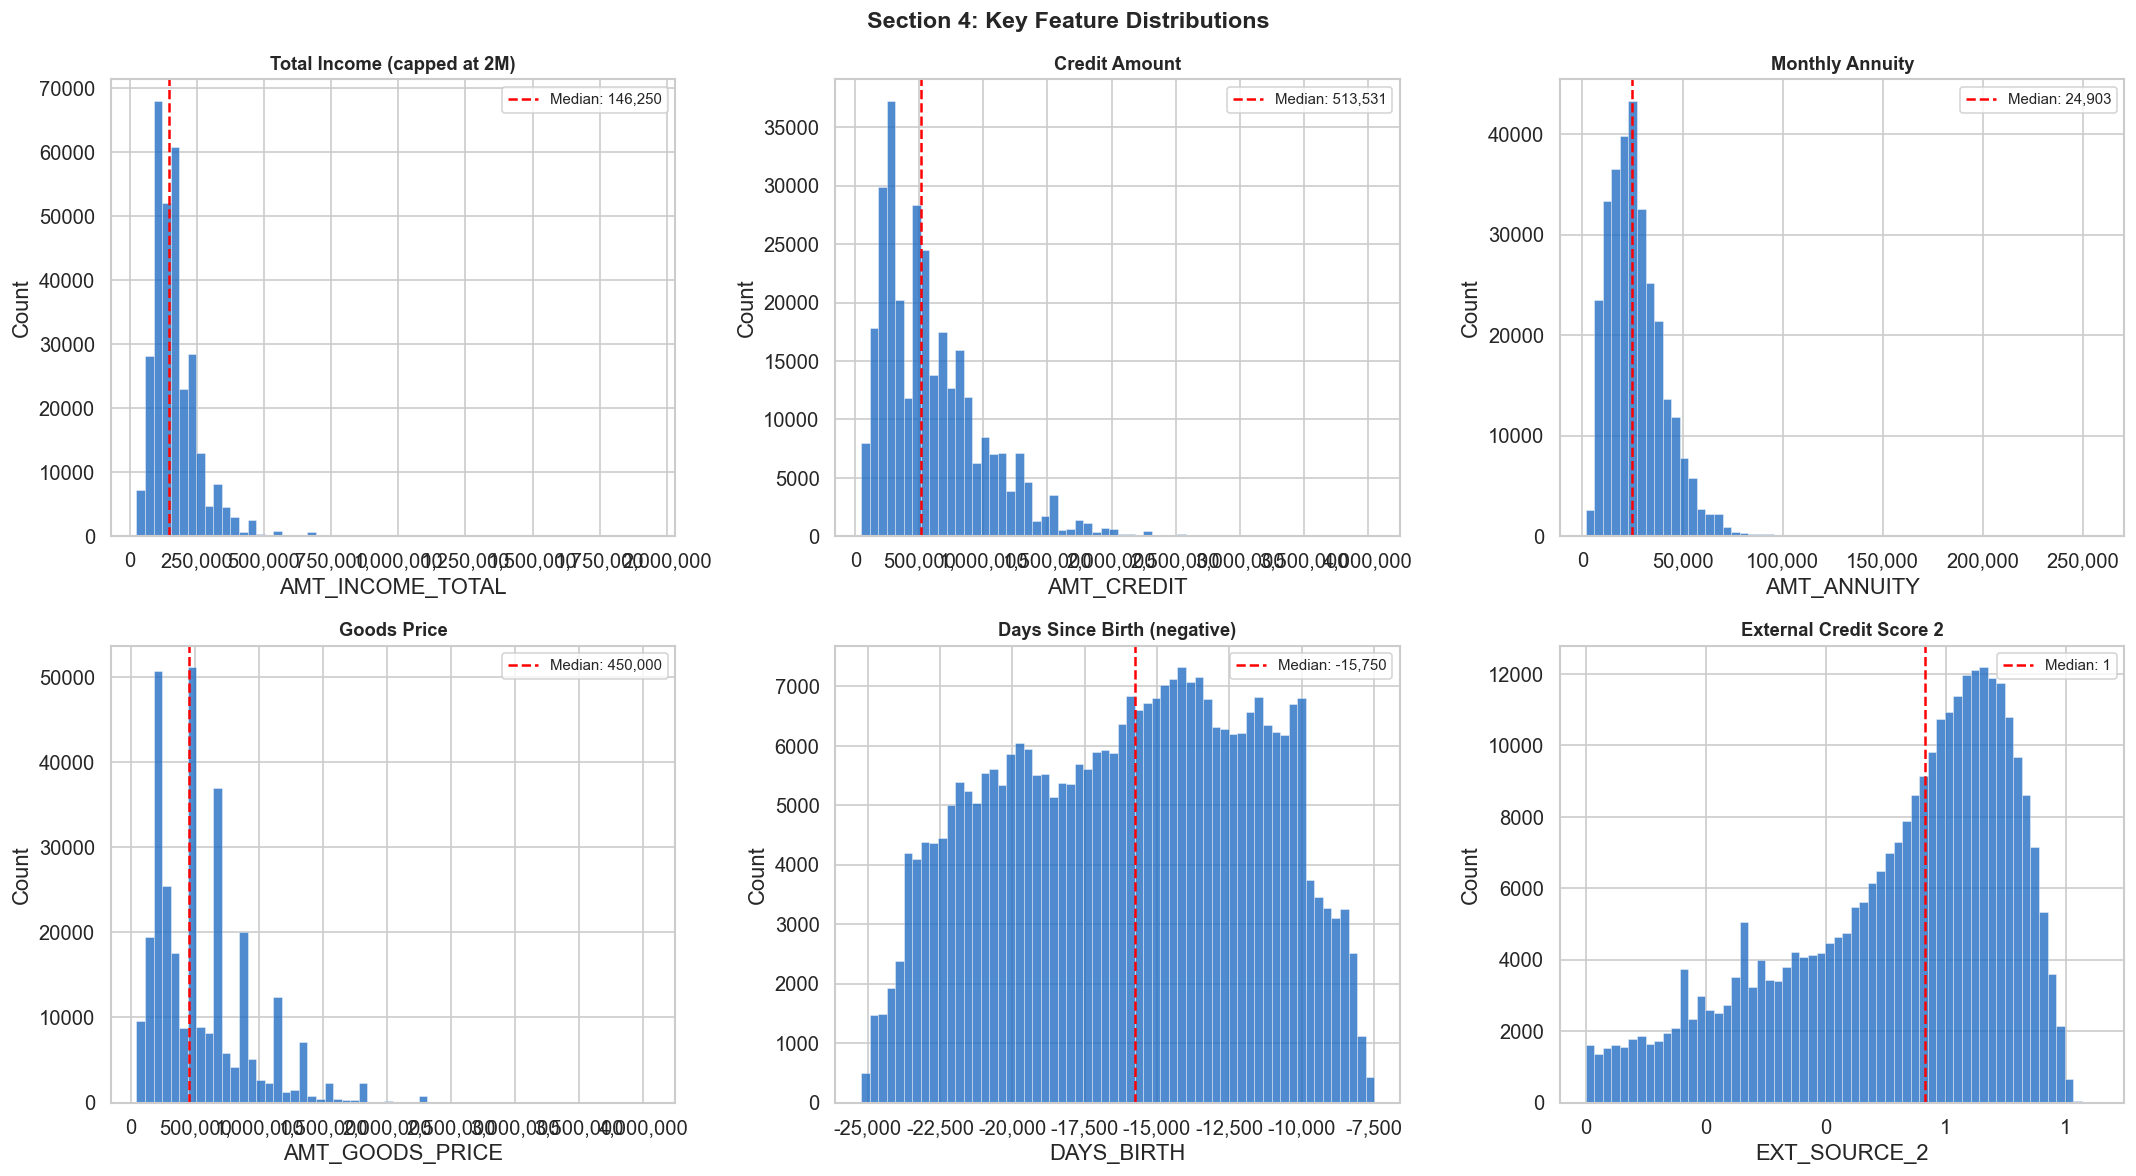

Sentinel records by income type:
NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Default rate - sentinel : 0.054


Default rate - non-sent.: 0.087


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

key_feats = [
    ('AMT_INCOME_TOTAL', 'Total Income (capped at 2M)'),
    ('AMT_CREDIT',       'Credit Amount'),
    ('AMT_ANNUITY',      'Monthly Annuity'),
    ('AMT_GOODS_PRICE',  'Goods Price'),
    ('DAYS_BIRTH',       'Days Since Birth (negative)'),
    ('EXT_SOURCE_2',     'External Credit Score 2'),
]

for ax, (col, title) in zip(axes.flat, key_feats):
    data = app[col].dropna()
    if col == 'AMT_INCOME_TOTAL': data = data[data <= 2e6]
    if col == 'DAYS_EMPLOYED':   data = data[data != 365243]
    ax.hist(data, bins=60, color='#1565C0', alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():,.0f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Section 4: Key Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# DAYS_EMPLOYED sentinel breakdown
sent = app[app['DAYS_EMPLOYED'] == 365243]
print('Sentinel records by income type:')
print(sent['NAME_INCOME_TYPE'].value_counts().to_string())
print(f'Default rate - sentinel : {sent["TARGET"].mean():.3f}')
print(f'Default rate - non-sent.: {app[app["DAYS_EMPLOYED"]!=365243]["TARGET"].mean():.3f}')

### What we found

**Income (`AMT_INCOME_TOTAL`) is extremely skewed.** Median currency units 147,150, mean currency units 168,798, maximum currency units 117,000,000. The jump from the 99th percentile (currency units 472,500) to that maximum points to a tiny group of ultra-high-income applicants who do not represent the population. A log transform is non-negotiable before any distance calculation, and we winsorize at the 99th percentile first so the cap does not get swallowed by the tail.

**Credit amount (`AMT_CREDIT`)** is right-skewed (skewness 1.23) but much milder than income. Median currency units 513,531, max currency units 4,050,000, with most loans bunched around currency units 450K to currency units 600K and a long tail. A log transform helps here too.

**Annuity (`AMT_ANNUITY`)** is right-skewed (1.58); median monthly payment currency units 24,903, max currency units 258,025. Its shape tracks credit amount, which makes sense since the annuity is bounded by the loan size and rate.

**Age (`DAYS_BIRTH`) is stored as negative integers** (days since birth, so always negative). The range −25,229 to −7,489 works out to ages 20.5 to 69.1, a clean symmetric spread with nothing anomalous. We convert it to positive years for readability.

**`DAYS_EMPLOYED` hides a sentinel.** The value 365,243 (exactly 1,000 years in days) shows up in 55,374 records, 18.0% of the data, and every one of them is a pensioner (55,352) or unemployed (22). This is a deliberate placeholder, not a typo: employment duration simply does not apply to those states. The group's 5.4% default rate against 8.7% for everyone else confirms it marks a real behavioural difference. We flag it with `FLAG_SENTINEL_EMPLOYED` and replace the 365,243 with NaN.

**External scores (`EXT_SOURCE_1/2/3`)** all live in [0,1]. Their near-zero mutual correlations (r < 0.22) say they measure independent things from different bureaus, and together they are the strongest single predictors of default in Section 7. `EXT_SOURCE_1`'s 56% missingness is the trickiest handling problem in the whole dataset.

---
## Section 5: Categorical features

### What we are checking, and why

Categorical variables are what let us describe a cluster in plain language later, the difference between "Cluster 3" and "young salaried urban applicants" or "pensioners who own property." So we need to know now how much each one can actually separate people.

We are watching for three things: features with many distinct values (high cardinality), features dominated by one category above 90% (which carry little separating power), and catch-all codes like `XNA`, `Other`, or `Unknown` that hide real meaning. We also note here how each variable should be encoded for clustering, since that choice depends on whether the categories have a natural order.

In [8]:
cat_cols = app.select_dtypes(include='object').columns.tolist()

cat_summary = []
for col in cat_cols:
    vc = app[col].value_counts(dropna=True)
    n_unique = app[col].nunique(dropna=True)
    dominant_pct = vc.iloc[0] / len(app) * 100 if len(vc) > 0 else 0
    n_xna = app[col].isin(['XNA','Unknown','XAP','Other','not specified']).sum()
    cat_summary.append({'column': col, 'n_unique': n_unique,
                        'dominant_category': str(vc.index[0]) if len(vc)>0 else 'N/A',
                        'dominant_pct': round(dominant_pct, 1),
                        'xna_count': n_xna,
                        'missing_pct': round(app[col].isna().mean()*100, 1)})

cat_df = pd.DataFrame(cat_summary).sort_values('dominant_pct', ascending=False)
print(cat_df.to_string(index=False))

low_var = cat_df[cat_df['dominant_pct'] >= 88]
print(f'\nLow-variance categoricals (dominant >= 88%):')
for _, row in low_var.iterrows():
    print(f'  {row["column"]}: {repr(row["dominant_category"])} = {row["dominant_pct"]}%')

                    column  n_unique             dominant_category  dominant_pct  xna_count  missing_pct
        NAME_CONTRACT_TYPE         2                    Cash loans       90.5000          0       0.0000
         NAME_HOUSING_TYPE         6             House / apartment       88.7000          0       0.0000
           NAME_TYPE_SUITE         7                 Unaccompanied       80.8000          0       0.4000
       NAME_EDUCATION_TYPE         5 Secondary / secondary special       71.0000          0       0.0000
           FLAG_OWN_REALTY         2                             Y       69.4000          0       0.0000
              FLAG_OWN_CAR         2                             N       66.0000          0       0.0000
               CODE_GENDER         3                             F       65.8000          4       0.0000
        NAME_FAMILY_STATUS         6                       Married       63.9000          2       0.0000
       EMERGENCYSTATE_MODE         2                   

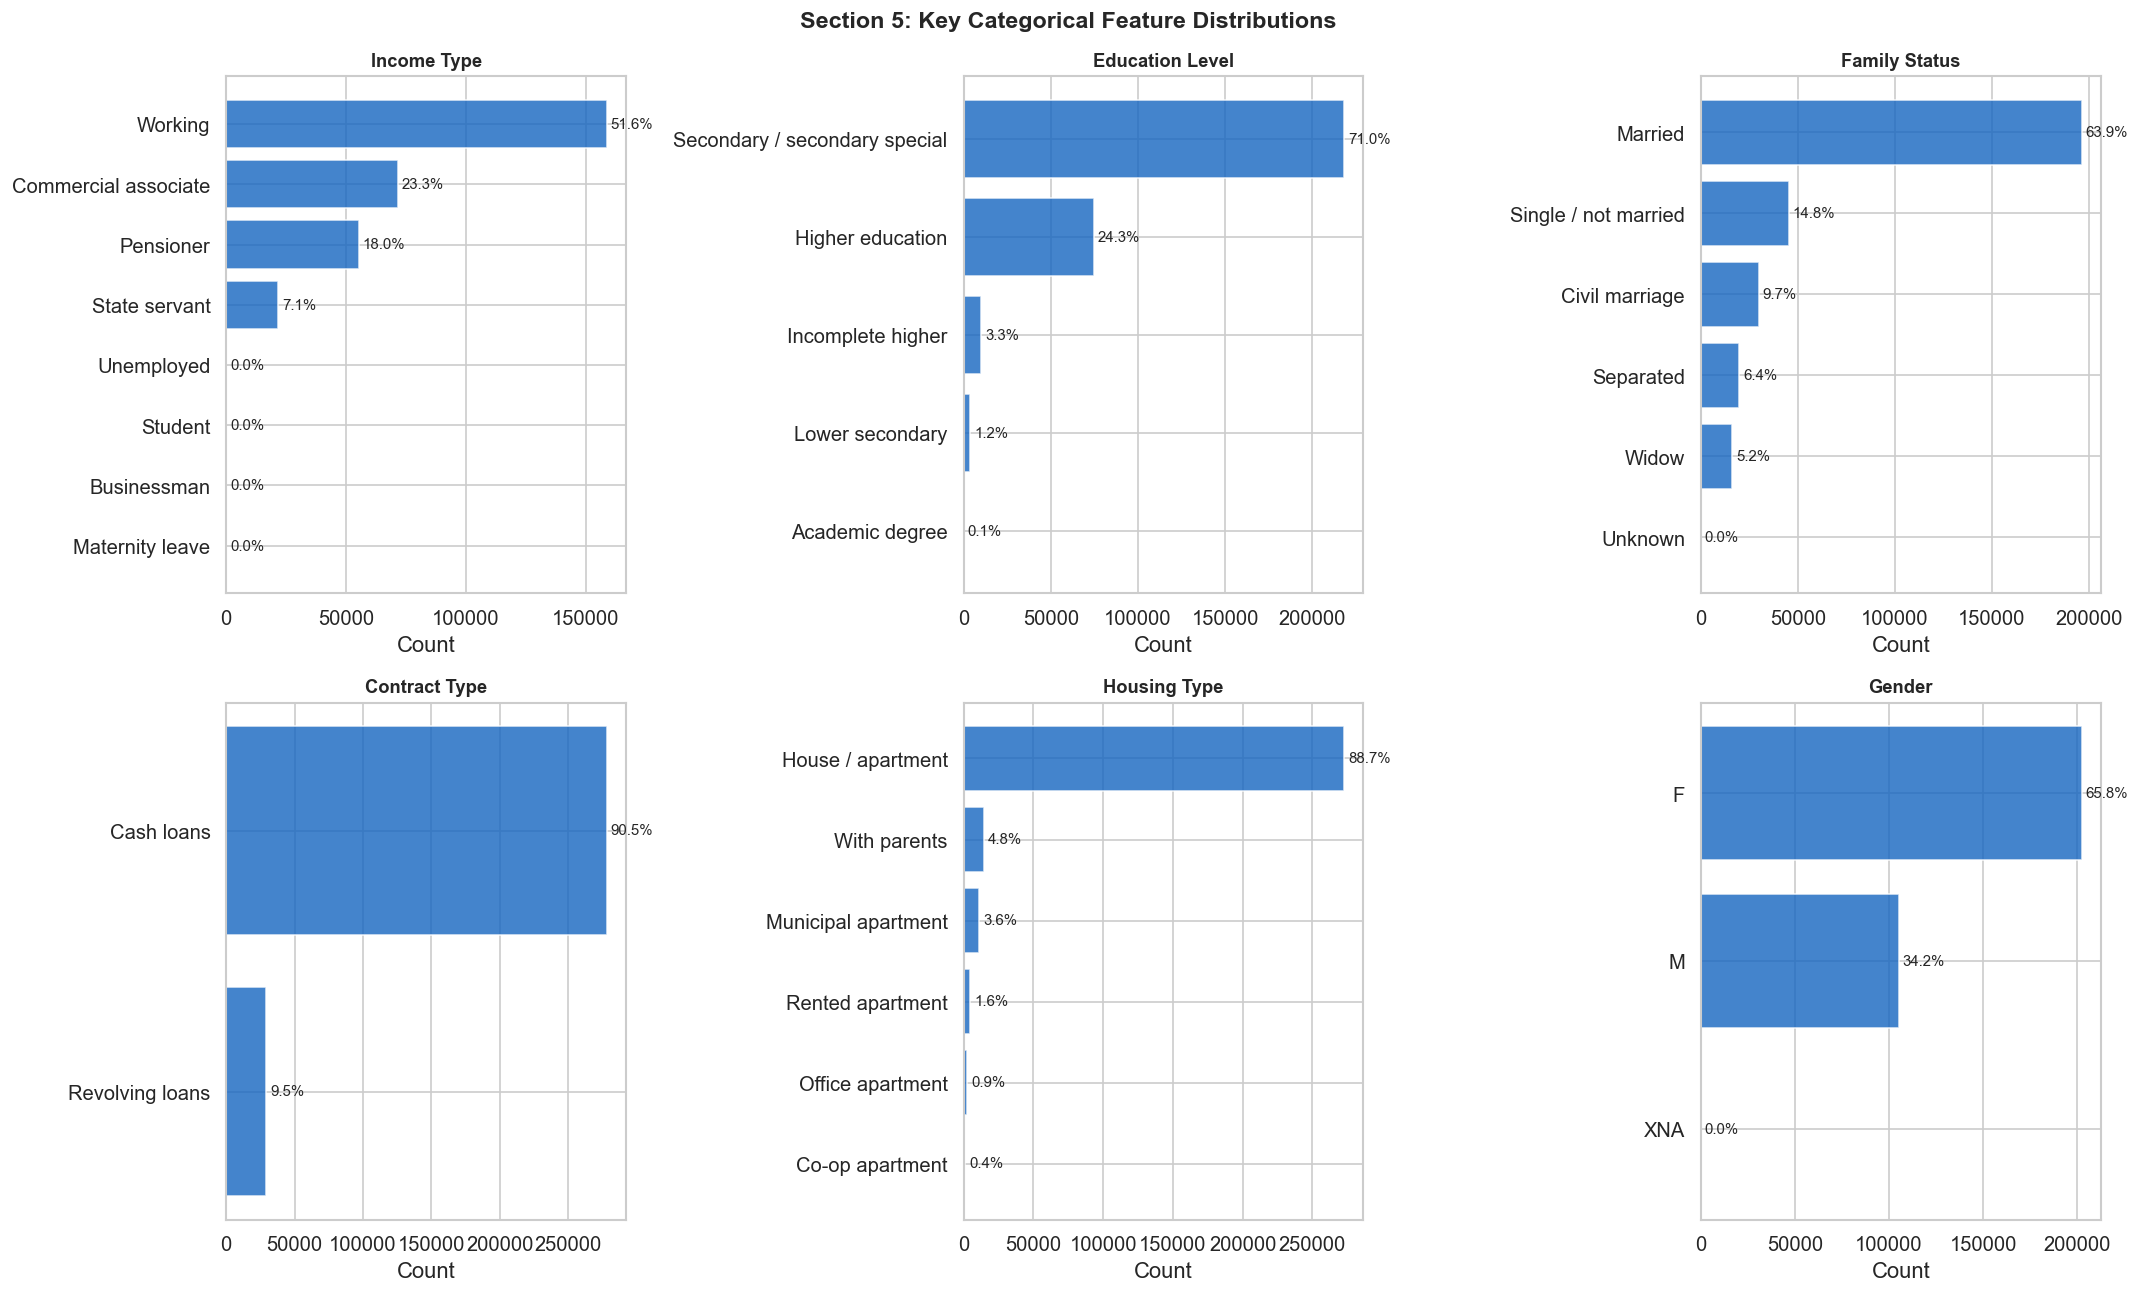


ORGANIZATION_TYPE: top 12 categories
ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Total unique: 58


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

plot_cols = [
    ('NAME_INCOME_TYPE', 'Income Type'),
    ('NAME_EDUCATION_TYPE', 'Education Level'),
    ('NAME_FAMILY_STATUS', 'Family Status'),
    ('NAME_CONTRACT_TYPE', 'Contract Type'),
    ('NAME_HOUSING_TYPE', 'Housing Type'),
    ('CODE_GENDER', 'Gender'),
]

for ax, (col, title) in zip(axes.flat, plot_cols):
    vc = app[col].value_counts(dropna=True).head(10)
    ax.barh(vc.index[::-1], vc.values[::-1], color='#1565C0', alpha=0.8)
    for i, (idx, val) in enumerate(vc.items()):
        ax.text(val + vc.max()*0.01, len(vc)-1-i, f'{val/len(app)*100:.1f}%', va='center', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Count')

plt.suptitle('Section 5: Key Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nORGANIZATION_TYPE: top 12 categories')
print(app['ORGANIZATION_TYPE'].value_counts().head(12).to_string())
print(f'Total unique: {app["ORGANIZATION_TYPE"].nunique()}')

### What we found

**`NAME_CONTRACT_TYPE`** is binary: Cash loans 90.5%, Revolving loans 9.5%. The lopsided split mirrors Home Credit's product mix. Encoded as a single 0/1.

**`CODE_GENDER`** is 65.8% female, 34.2% male, with 4 records coded `XNA` (data-entry errors or institutional applicants). We treat those 4 as missing. Encoded as a single 0/1.

**`NAME_INCOME_TYPE`** is dominated by Working (51.6%), Commercial associate (23.3%), Pensioner (18.0%), and State servant (7.1%), which together cover 99.9% of rows. The leftovers (Unemployed 22, Student 18, Businessman 10, Maternity leave 5) are tiny but carry extreme default rates (Unemployed 36.4%, Maternity leave 40.0%), so we fold them into a single `Other_Rare` group rather than let them form unstable fragments.

**`NAME_EDUCATION_TYPE`** is concentrated in Secondary (71.0%) and Higher education (24.3%), with Lower secondary (1.2%) and Academic degree (0.1%) sparse. The key point is that education has a real order, from Lower secondary up to Academic degree, so it is an ordinal variable, not an unordered list.

**`ORGANIZATION_TYPE`** has high cardinality (58 distinct values), and 18.0% are coded `XNA`, exactly matching the `DAYS_EMPLOYED` sentinel share. Those are the pensioners and unemployed for whom an employer does not apply. We first collapse the ~50 granular business-entity labels into about a dozen macro-sectors.

**Low-variance features** like `NAME_CONTRACT_TYPE` (90.5% one value), `NAME_HOUSING_TYPE` (88.7%), and `NAME_TYPE_SUITE` (80.8%) add little to distance-based separation and are candidates for exclusion.

**How these get encoded for clustering (and why not one-hot).** K-Means measures Euclidean distance, and one-hot encoding hurts it twice over: it adds many sparse binary columns that collectively outweigh a single real feature, and it forces every category to sit the same distance from every other, even when some are clearly more alike. So we match the encoding to the variable:

- `NAME_EDUCATION_TYPE` becomes a single ordinal integer 0-4 (Lower secondary to Academic degree). One ordered number keeps "Higher education is closer to Incomplete higher than to Lower secondary," which one-hot throws away.
- `NAME_INCOME_TYPE` and `ORGANIZATION_TYPE` are nominal with no order, so each becomes one frequency-encoded column: we replace the category with how common it is, collapsing the whole variable into a single "mainstream  to  niche" axis. Pensioners stay separately identified by `FLAG_SENTINEL_EMPLOYED`, so this does not recreate the perfect collinearity that one-hot produced in an earlier run.

---
## Section 6: Outliers, and what kind they are

### What we are checking, and why

Not all outliers are the same, and treating them the same is a mistake. In financial data they come in three flavours: impossible values that are simply wrong (age under 18, negative income), sentinel placeholders deliberately inserted to encode a state, and genuine extremes that are real but rare (a very high income). Each needs a different response.

We flag with IQR x 3 rather than the usual 1.5x, because financial distributions are naturally heavy-tailed and 1.5x would brand ordinary high earners as outliers. This section also sets up Phase 4: the three-way typology we define here is exactly how we will later sort the anomalies that phase finds.

                  column          IQR_lo         IQR_hi  n_outliers  pct_outliers       actual_max
        AMT_INCOME_TOTAL   -157,500.0000   472,500.0000        3014        0.9800 117,000,000.0000
              AMT_CREDIT -1,345,950.0000 2,424,600.0000         444        0.1400   4,050,000.0000
             AMT_ANNUITY    -37,692.0000    88,812.0000        1024        0.3300     258,025.5000
         AMT_GOODS_PRICE -1,084,500.0000 2,002,500.0000        1090        0.3500   4,050,000.0000
           DAYS_EMPLOYED    -10,399.0000     6,457.0000        3832        1.2500     365,243.0000
            CNT_CHILDREN         -3.0000         4.0000         126        0.0400          19.0000
         CNT_FAM_MEMBERS         -1.0000         6.0000         121        0.0400          20.0000
OBS_30_CNT_SOCIAL_CIRCLE         -6.0000         8.0000        6161        2.0000         348.0000
DEF_30_CNT_SOCIAL_CIRCLE          0.0000         0.0000       35166       11.4400          34.0000
OBS_60_CNT

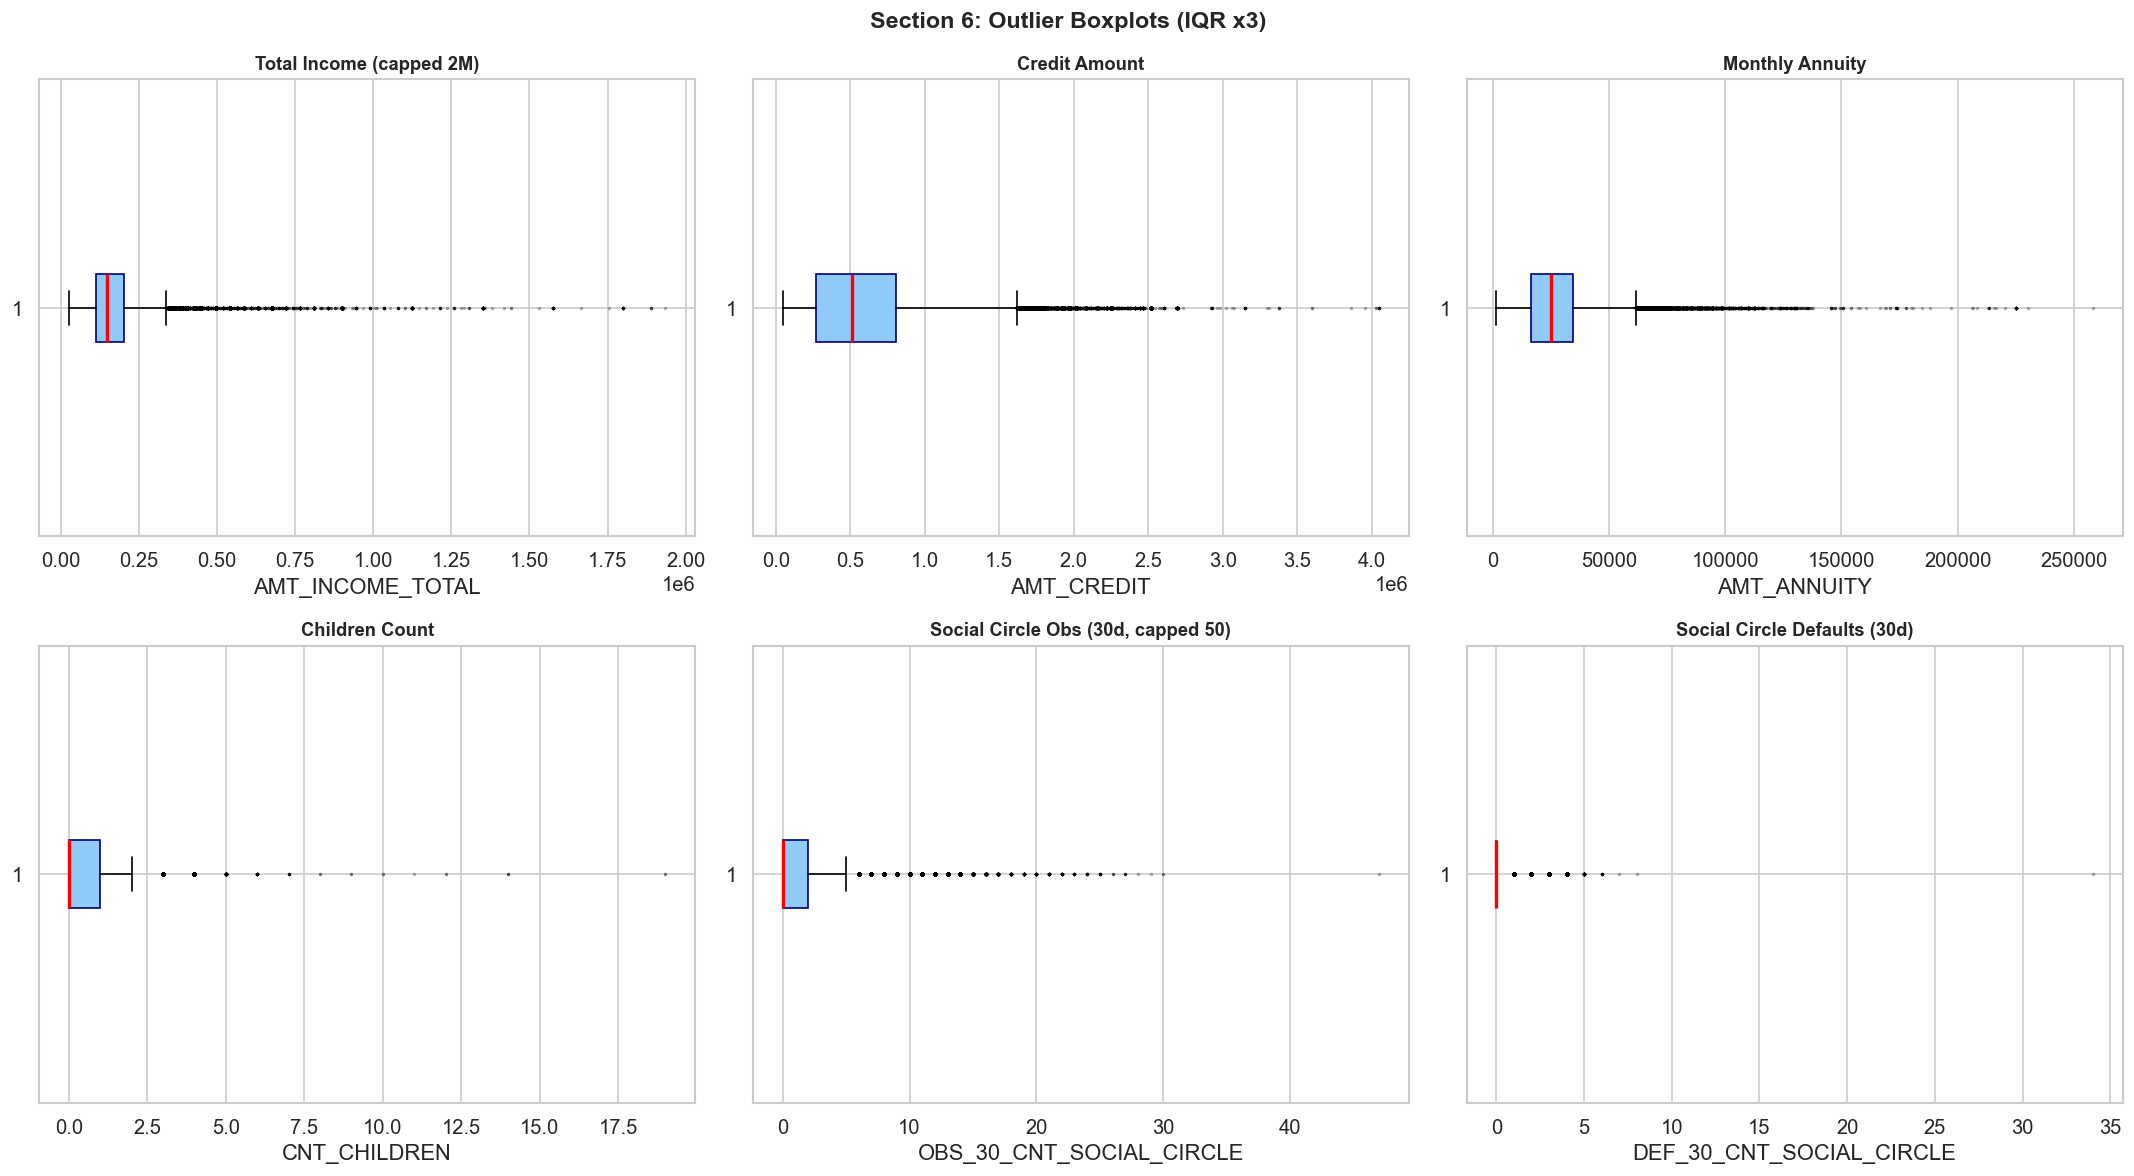


=== AMT_INCOME_TOTAL Extremes ===
p99: 472,500
max: 117,000,000
Records above 1M: 250


In [10]:
key_num = ['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE',
           'DAYS_EMPLOYED','CNT_CHILDREN','CNT_FAM_MEMBERS',
           'OBS_30_CNT_SOCIAL_CIRCLE','DEF_30_CNT_SOCIAL_CIRCLE',
           'OBS_60_CNT_SOCIAL_CIRCLE','DEF_60_CNT_SOCIAL_CIRCLE']

outlier_report = []
for col in key_num:
    if col not in app.columns: continue
    data = app[col].dropna()
    if col == 'DAYS_EMPLOYED': data = data[data != 365243]
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 3*IQR, Q3 + 3*IQR
    n_out = ((app[col] < lo) | (app[col] > hi))
    if col == 'DAYS_EMPLOYED': n_out = n_out & (app[col] != 365243)
    n_out = n_out.sum()
    outlier_report.append({'column': col, 'IQR_lo': round(lo,1), 'IQR_hi': round(hi,1),
                           'n_outliers': n_out, 'pct_outliers': round(n_out/len(app)*100, 2),
                           'actual_max': app[col].max()})

out_df = pd.DataFrame(outlier_report)
print(out_df[['column','IQR_lo','IQR_hi','n_outliers','pct_outliers','actual_max']].to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
box_cols = [('AMT_INCOME_TOTAL',2e6,'Total Income (capped 2M)'),
            ('AMT_CREDIT',None,'Credit Amount'),
            ('AMT_ANNUITY',None,'Monthly Annuity'),
            ('CNT_CHILDREN',None,'Children Count'),
            ('OBS_30_CNT_SOCIAL_CIRCLE',50,'Social Circle Obs (30d, capped 50)'),
            ('DEF_30_CNT_SOCIAL_CIRCLE',None,'Social Circle Defaults (30d)')]

for ax, (col, cap, title) in zip(axes.flat, box_cols):
    data = app[col].dropna()
    if col == 'DAYS_EMPLOYED': data = data[data != 365243]
    if cap: data = data[data <= cap]
    ax.boxplot(data, vert=False, patch_artist=True,
               boxprops=dict(facecolor='#90CAF9', color='navy'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(col)

plt.suptitle('Section 6: Outlier Boxplots (IQR x3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== AMT_INCOME_TOTAL Extremes ===')
print(f'p99: {app["AMT_INCOME_TOTAL"].quantile(0.99):,.0f}')
print(f'max: {app["AMT_INCOME_TOTAL"].max():,.0f}')
print(f'Records above 1M: {(app["AMT_INCOME_TOTAL"] > 1e6).sum()}')

### What we found

**Sentinel value: `DAYS_EMPLOYED = 365,243` (18.0% of records).** The same placeholder from Section 4: exactly 1,000 years in days, all 55,374 of them pensioners or unemployed. The 5.4% default rate against 8.7% elsewhere confirms it encodes a real state. We flag it and replace it with NaN, rather than letting a 1,000-year tenure wreck every distance.

**Genuine extremes: `AMT_INCOME_TOTAL` above currency units 1M (250 records).** These are not errors. The currency units 117M maximum is a true outlier, but the broader high-income group is an economically real segment, and deleting it would erase a meaningful population. We winsorize at the 99th percentile (currency units 472,500) and then log-transform, which tames the extreme without discarding anyone.

**Real but easy to misread: `DEF_30_CNT_SOCIAL_CIRCLE` (11.4% flagged).** The 11.4% "outlier" rate just reflects that most applicants have zero social-circle defaults while about one in nine has at least one. Calling that group outliers is misleading; they are a distinct behavioural sub-population (people with credit risk close to them socially), not noise. We bin into 0 / 1 / 2+ and deliberately do not winsorize.

**`CNT_CHILDREN` topping out at 19.** 126 records report more than 4 children, and a literal count of 19 is biologically implausible as direct offspring, so it is likely a data-entry issue. We cap counts above 10 at a defensible limit.

---
## Section 7: Feature Correlation Analysis

### What We Are Investigating and Why

Correlation analysis serves two downstream purposes: **feature selection** (identifying redundant features) and **feature interpretation** (understanding what each retained feature actually represents).

We compute the Pearson correlation matrix for all numerical features, visualize it as a heatmap, and examine correlation with `TARGET` to understand which features carry the strongest signal for distinguishing defaulters from non-defaulters.

Top 15 features by absolute correlation with TARGET:
EXT_SOURCE_3                  0.1789
EXT_SOURCE_2                  0.1605
EXT_SOURCE_1                  0.1553
DAYS_BIRTH                    0.0782
REGION_RATING_CLIENT_W_CITY   0.0609
REGION_RATING_CLIENT          0.0589
DAYS_LAST_PHONE_CHANGE        0.0552
DAYS_ID_PUBLISH               0.0515
REG_CITY_NOT_WORK_CITY        0.0510
FLAG_EMP_PHONE                0.0460
DAYS_EMPLOYED                 0.0449
REG_CITY_NOT_LIVE_CITY        0.0444
FLAG_DOCUMENT_3               0.0443
FLOORSMAX_AVG                 0.0440
FLOORSMAX_MEDI                0.0438


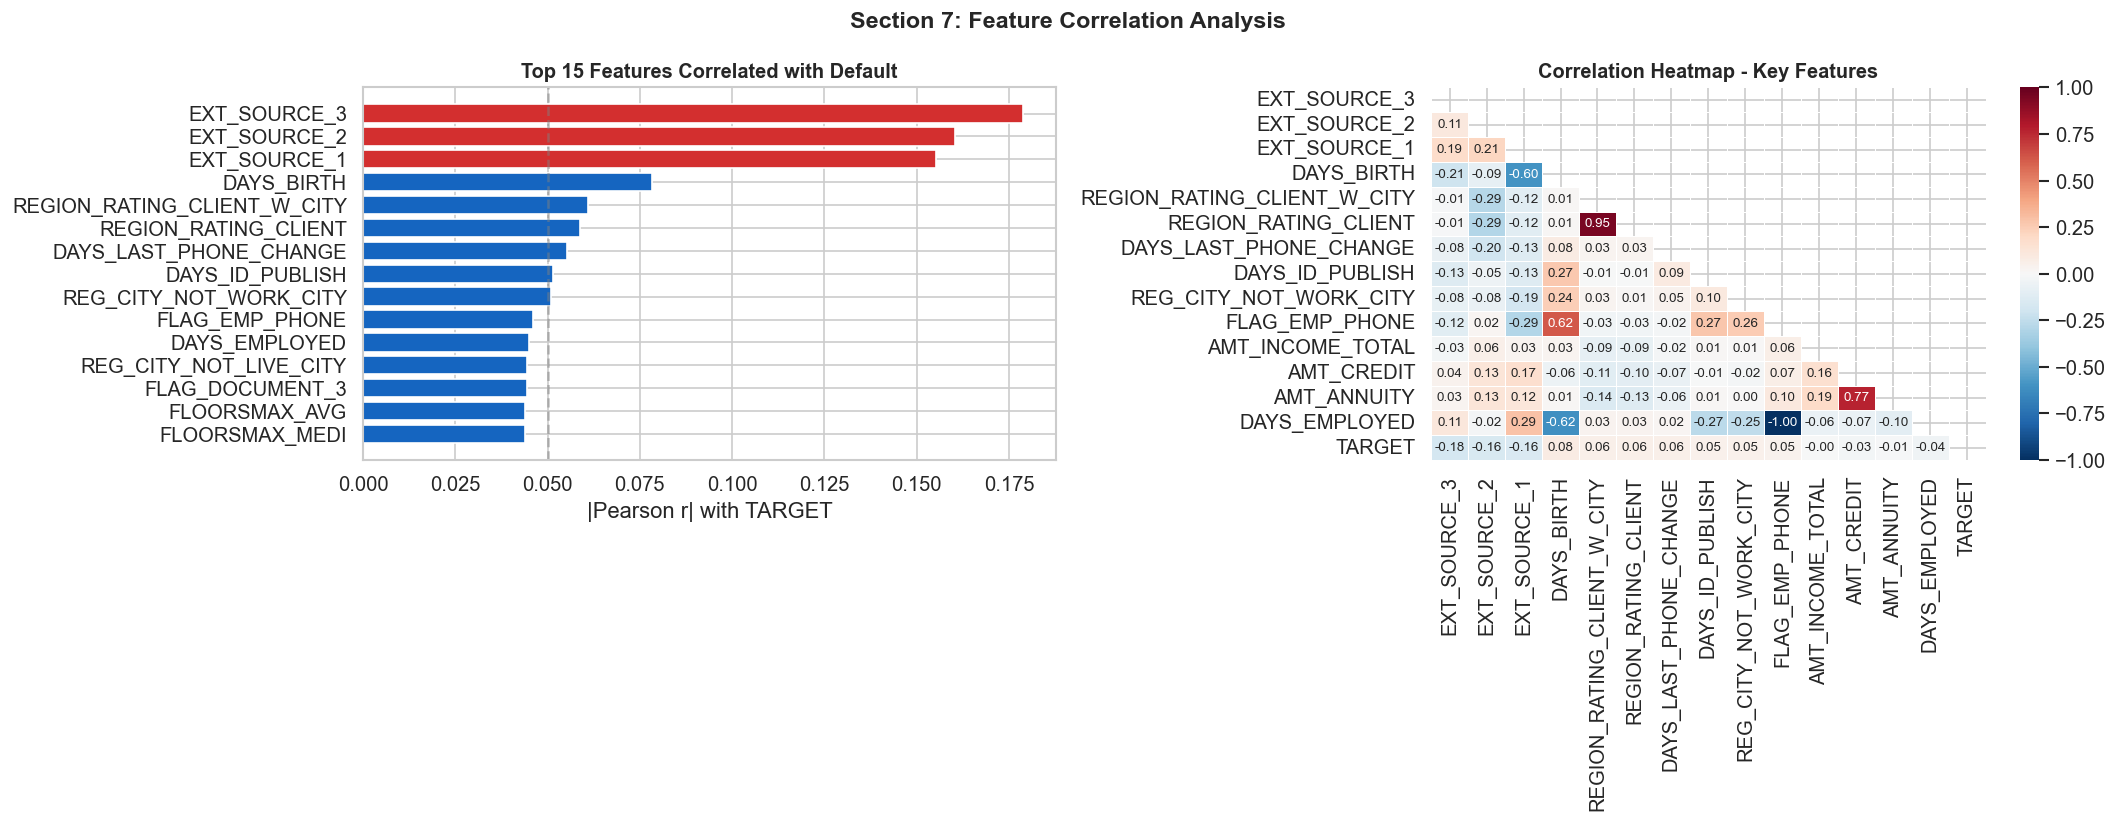

In [11]:
num_cols_full = app.select_dtypes(include=np.number).columns.difference(['SK_ID_CURR'])
corr_target = app[num_cols_full].corr()['TARGET'].drop('TARGET').abs().sort_values(ascending=False)

print('Top 15 features by absolute correlation with TARGET:')
print(corr_target.head(15).to_string())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
top15 = corr_target.head(15)
colors_bar = ['#D32F2F' if 'EXT_SOURCE' in c else '#1565C0' for c in top15.index]
ax.barh(top15.index[::-1], top15.values[::-1], color=colors_bar[::-1])
ax.set_xlabel('|Pearson r| with TARGET')
ax.set_title('Top 15 Features Correlated with Default', fontsize=12, fontweight='bold')
ax.axvline(0.05, color='gray', linestyle='--', alpha=0.5)

ax = axes[1]
selected = list(corr_target.head(10).index) + ['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','DAYS_EMPLOYED']
selected = list(dict.fromkeys(selected))
corr_sub = app[selected + ['TARGET']].corr()
mask = np.triu(np.ones_like(corr_sub, dtype=bool))
sns.heatmap(corr_sub, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Correlation Heatmap - Key Features', fontsize=12, fontweight='bold')

plt.suptitle('Section 7: Feature Correlation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
print('=== Highly correlated feature pairs (|r| > 0.85) ===')
num_only = app.select_dtypes(include=np.number).columns.difference(['SK_ID_CURR','TARGET'])
corr_matrix = app[num_only].corr()

high_corr_pairs = []
cols_list = corr_matrix.columns.tolist()
for i in range(len(cols_list)):
    for j in range(i+1, len(cols_list)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            high_corr_pairs.append((cols_list[i], cols_list[j], r))

high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print(f'Total pairs with |r| > 0.85: {len(high_corr_pairs)}')
print('\nTop 20:')
for c1, c2, r in high_corr_pairs[:20]:
    print(f'  {c1:<40} vs  {c2:<35}  r={r:.3f}')

=== Highly correlated feature pairs (|r| > 0.85) ===


Total pairs with |r| > 0.85: 89

Top 20:
  DAYS_EMPLOYED                            vs  FLAG_EMP_PHONE                       r=-1.000
  YEARS_BUILD_AVG                          vs  YEARS_BUILD_MEDI                     r=0.998
  OBS_30_CNT_SOCIAL_CIRCLE                 vs  OBS_60_CNT_SOCIAL_CIRCLE             r=0.998
  FLOORSMIN_AVG                            vs  FLOORSMIN_MEDI                       r=0.997
  FLOORSMAX_AVG                            vs  FLOORSMAX_MEDI                       r=0.997
  ENTRANCES_AVG                            vs  ENTRANCES_MEDI                       r=0.997
  ELEVATORS_AVG                            vs  ELEVATORS_MEDI                       r=0.996
  COMMONAREA_AVG                           vs  COMMONAREA_MEDI                      r=0.996
  LIVINGAREA_AVG                           vs  LIVINGAREA_MEDI                      r=0.996
  APARTMENTS_AVG                           vs  APARTMENTS_MEDI                      r=0.995
  BASEMENTAREA_AVG                    

### What we found

**The external scores lead, by a clear margin.** The three strongest predictors of default are `EXT_SOURCE_3` (|r| = 0.179), `EXT_SOURCE_2` (|r| = 0.160), and `EXT_SOURCE_1` (|r| = 0.155). These look modest in absolute terms, which is normal for messy human behaviour, but they are the most predictive single columns we have, and that fits domain sense: an external score compresses years of repayment history into one number.

**Age matters a little (|r| = 0.078).** Older applicants default less. Because `DAYS_BIRTH` is negative (older is more negative), the positive sign against `TARGET` means younger applicants default more.

**89 highly correlated pairs (|r| > 0.85),** almost all of them one of three kinds of redundancy. First, the `_AVG`/`_MODE`/`_MEDI` triplication at r ~ 0.99: every building measurement exists three times, and keeping all three would triple its weight in distance, so we keep `_MODE` and drop the other two. Second, `DAYS_EMPLOYED` versus `FLAG_EMP_PHONE` at r = −1.0, perfectly redundant once the sentinel is handled, so `FLAG_EMP_PHONE` goes. Third, `OBS_30` versus `OBS_60` at r = 0.998, the same social-network count over two time windows, so we keep the 30-day one.

Worth stressing: `EXT_SOURCE_1/2/3` are *not* redundant with each other (r = 0.11 to 0.21). Each is a different bureau's read, so all three stay. Several `FLAG_DOCUMENT_*` flags sit near zero correlation with everything; if they matter at all, it is through interactions, not on their own.

---
## Section 7: Correlation

### What we are checking, and why

Correlation does two jobs for us. It finds redundant features, where two columns say the same thing and one can go, and it helps us interpret what a retained feature really stands for. We compute the Pearson matrix across the numeric features, read it as a heatmap, and look specifically at correlation with `TARGET` to see which features best separate defaulters from non-defaulters.

In [13]:
print('=== BUREAU: External Credit History ===')
bureau_counts = bureau.groupby('SK_ID_CURR').size()
n_app = app['SK_ID_CURR'].nunique()
print(f'Applicants with bureau records : {bureau_counts.shape[0]:,} ({bureau_counts.shape[0]/n_app*100:.1f}%)')
print(f'Applicants WITHOUT bureau      : {n_app - bureau_counts.shape[0]:,} ({(n_app-bureau_counts.shape[0])/n_app*100:.1f}%)')
print(f'Records per applicant: p25={bureau_counts.quantile(0.25):.0f}  p50={bureau_counts.quantile(0.5):.0f}  p75={bureau_counts.quantile(0.75):.0f}  p95={bureau_counts.quantile(0.95):.0f}  max={bureau_counts.max()}')
print('\nCredit active status:')
print(bureau['CREDIT_ACTIVE'].value_counts().to_string())

print('\n=== PREVIOUS APPLICATION ===')
prev_counts = prev.groupby('SK_ID_CURR').size()
print(f'Records: {len(prev):,}  |  Unique applicants: {prev_counts.shape[0]:,}')
print(f'Apps per applicant: p50={prev_counts.median():.0f}  p95={prev_counts.quantile(0.95):.0f}')
print('Contract status:')
print(prev['NAME_CONTRACT_STATUS'].value_counts().to_string())
print(f'Historical approval rate: {(prev["NAME_CONTRACT_STATUS"]=="Approved").mean()*100:.1f}%')

print('\n=== INSTALLMENT PAYMENTS ===')
inst_copy = inst.copy()
inst_copy['DPD'] = (inst_copy['DAYS_ENTRY_PAYMENT'] - inst_copy['DAYS_INSTALMENT']).clip(lower=0)
print(f'Records: {len(inst):,}  |  Unique applicants: {inst["SK_ID_CURR"].nunique():,}')
print(f'Mean DPD: {inst_copy["DPD"].mean():.2f} days')
print(f'Late payments (DPD>0): {(inst_copy["DPD"]>0).mean()*100:.1f}%')
print(f'Severe late (DPD>30): {(inst_copy["DPD"]>30).mean()*100:.2f}%')

print('\n=== CREDIT CARD BALANCE ===')
cc_months = cc.groupby('SK_ID_CURR')['MONTHS_BALANCE'].nunique()
util = cc['AMT_BALANCE'] / cc['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)
print(f'Records: {len(cc):,}  |  Unique applicants: {cc["SK_ID_CURR"].nunique():,}')
print(f'Months of history: p50={cc_months.median():.0f}  p95={cc_months.quantile(0.95):.0f}')
print(f'Mean utilization: {util.mean()*100:.1f}%  |  median: {util.median()*100:.1f}%')

print('\n=== BUREAU BALANCE ===')
bb_months = bureau_bal.groupby('SK_ID_BUREAU')['MONTHS_BALANCE'].nunique()
print(f'Records: {len(bureau_bal):,}')
print(f'Observation window: {bureau_bal["MONTHS_BALANCE"].min()} to {bureau_bal["MONTHS_BALANCE"].max()} months')
print(f'History per bureau record: p50={bb_months.median():.0f}  p95={bb_months.quantile(0.95):.0f}')
print('\nMonthly status distribution:')
print(bureau_bal['STATUS'].value_counts().to_string())

=== BUREAU: External Credit History ===


Applicants with bureau records : 305,811 (99.4%)
Applicants WITHOUT bureau      : 1,700 (0.6%)
Records per applicant: p25=2  p50=4  p75=8  p95=14  max=116

Credit active status:
CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21

=== PREVIOUS APPLICATION ===


Records: 1,670,214  |  Unique applicants: 338,857
Apps per applicant: p50=4  p95=13
Contract status:
NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Historical approval rate: 62.1%

=== INSTALLMENT PAYMENTS ===


Records: 13,605,401  |  Unique applicants: 339,587
Mean DPD: 1.03 days


Late payments (DPD>0): 8.4%
Severe late (DPD>30): 0.28%

=== CREDIT CARD BALANCE ===


Records: 3,840,312  |  Unique applicants: 103,558
Months of history: p50=22  p95=96
Mean utilization: 37.5%  |  median: 1.1%

=== BUREAU BALANCE ===


Records: 27,299,925
Observation window: -96 to 0 months
History per bureau record: p50=26  p95=90

Monthly status distribution:


STATUS
C    13646993
0     7499507
X     5810482
1      242347
5       62406
2       23419
3        8924
4        5847


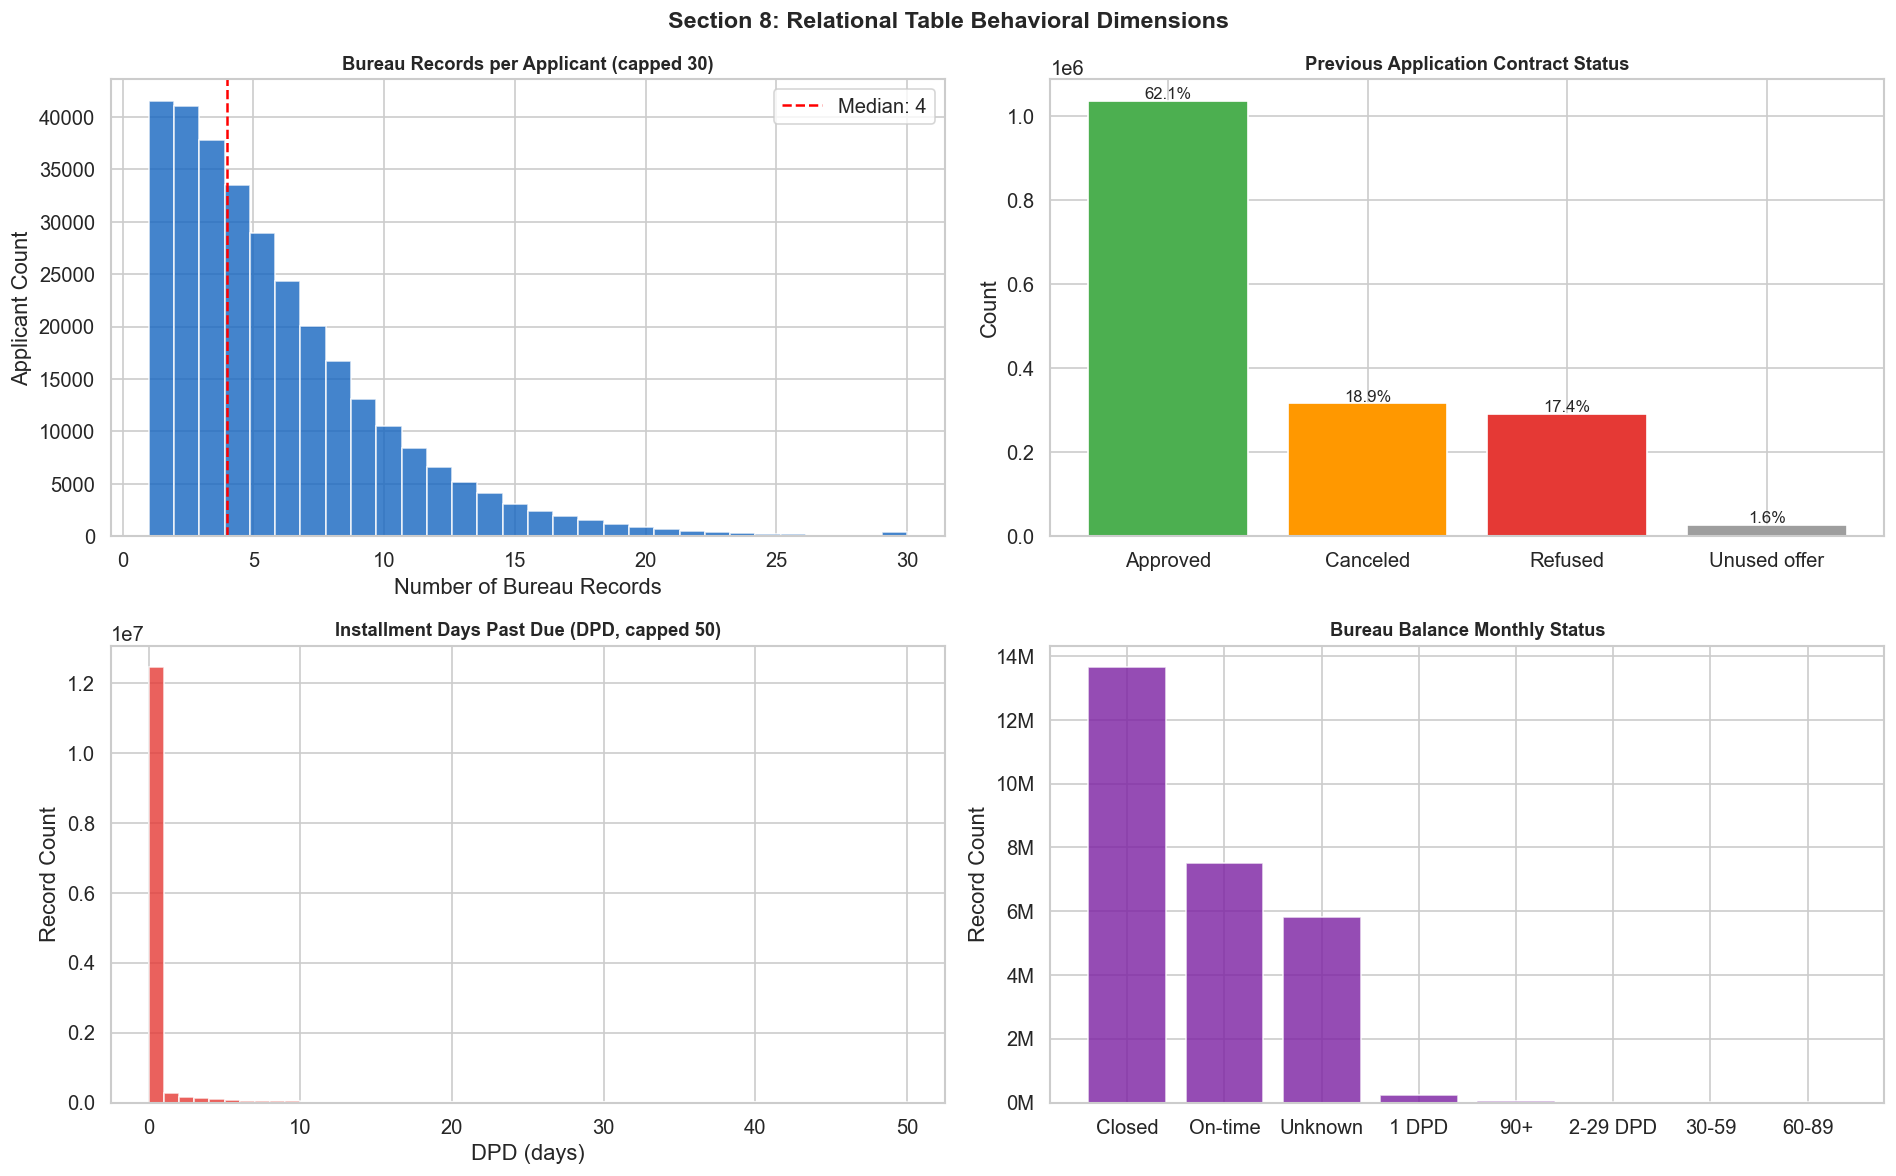

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.hist(bureau_counts.clip(upper=30), bins=30, color='#1565C0', alpha=0.8, edgecolor='white')
ax.set_title('Bureau Records per Applicant (capped 30)', fontsize=11, fontweight='bold')
ax.set_xlabel('Number of Bureau Records')
ax.set_ylabel('Applicant Count')
ax.axvline(bureau_counts.median(), color='red', linestyle='--', label=f'Median: {bureau_counts.median():.0f}')
ax.legend()

ax = axes[0, 1]
prev_status = prev['NAME_CONTRACT_STATUS'].value_counts()
ax.bar(prev_status.index, prev_status.values, color=['#4CAF50','#FF9800','#E53935','#9E9E9E'])
ax.set_title('Previous Application Contract Status', fontsize=11, fontweight='bold')
ax.set_ylabel('Count')
for bar, val in zip(ax.patches, prev_status.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5000,
            f'{val/len(prev)*100:.1f}%', ha='center', fontsize=10)

ax = axes[1, 0]
inst_copy2 = inst.copy()
inst_copy2['DPD'] = (inst_copy2['DAYS_ENTRY_PAYMENT'] - inst_copy2['DAYS_INSTALMENT']).clip(lower=0)
ax.hist(inst_copy2['DPD'].clip(upper=50), bins=50, color='#E53935', alpha=0.8, edgecolor='white')
ax.set_title('Installment Days Past Due (DPD, capped 50)', fontsize=11, fontweight='bold')
ax.set_xlabel('DPD (days)')
ax.set_ylabel('Record Count')

ax = axes[1, 1]
status_map = {'C':'Closed','0':'On-time','1':'1 DPD','2':'2-29 DPD','3':'30-59','4':'60-89','5':'90+','X':'Unknown'}
bb_status = bureau_bal['STATUS'].map(status_map).fillna(bureau_bal['STATUS']).value_counts()
ax.bar(bb_status.index, bb_status.values, color='#7B1FA2', alpha=0.8)
ax.set_title('Bureau Balance Monthly Status', fontsize=11, fontweight='bold')
ax.set_ylabel('Record Count')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.suptitle('Section 8: Relational Table Behavioral Dimensions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### What we found

**Bureau depth.** 99.4% of applicants have at least one external credit record, which says the credit infrastructure is mature. The median is 4 records (p75 = 8, p95 = 14, max = 116), a moderately skewed spread. About 63% of bureau credits are closed and 37% active; a high active-to-closed ratio can mark someone currently carrying a lot of leverage.

**Repayment quality from bureau balance.** This table covers 96 months (8 years). Its STATUS field codes C = closed, 0 = on-time, X = unknown, and 1 to 5 for worsening days-past-due. Closed (13.6M) and on-time (7.5M) records dominate, so histories are mostly healthy, but 242,347 records with 1+ DPD and 62,406 with 90+ DPD are real delinquency signals.

**Past applications as a selection signal.** 61.9% of previous applications were approved, and the 17.4% refusal rate is meaningful: someone refused before tends to be a different kind of risk. A median of 4 prior applications shows substantial earlier engagement with Home Credit.

**Actual repayment from installments.** 8.4% of historical installments were paid late (DPD > 0), with a mean of 1.03 days but a maximum of 2,884, so the tail is long. The applicants at that far tail are in sustained default, and once aggregated per person this becomes one of the strongest behavioural features we have.

**Revolving credit from card balances.** Mean utilization (balance over limit) and months of history will be the key aggregates; utilization above 80% is a classic sign of financial stress.

**Absence is itself a feature.** The 1,700 applicants with no bureau record are probably thin-file individuals, so `FLAG_NO_BUREAU` turns "we have no external history for this person" into a usable signal.

---
## Section 9: How features relate to each other

### What we are checking, and why

Single-feature distributions describe variables in isolation. But the clusters in Phase 2 will be defined by *combinations*, so understanding those combinations now means we can later explain a cluster precisely instead of hand-waving. We look at six pairs, each picked for a domain reason, and compare what we expected against what the data shows.

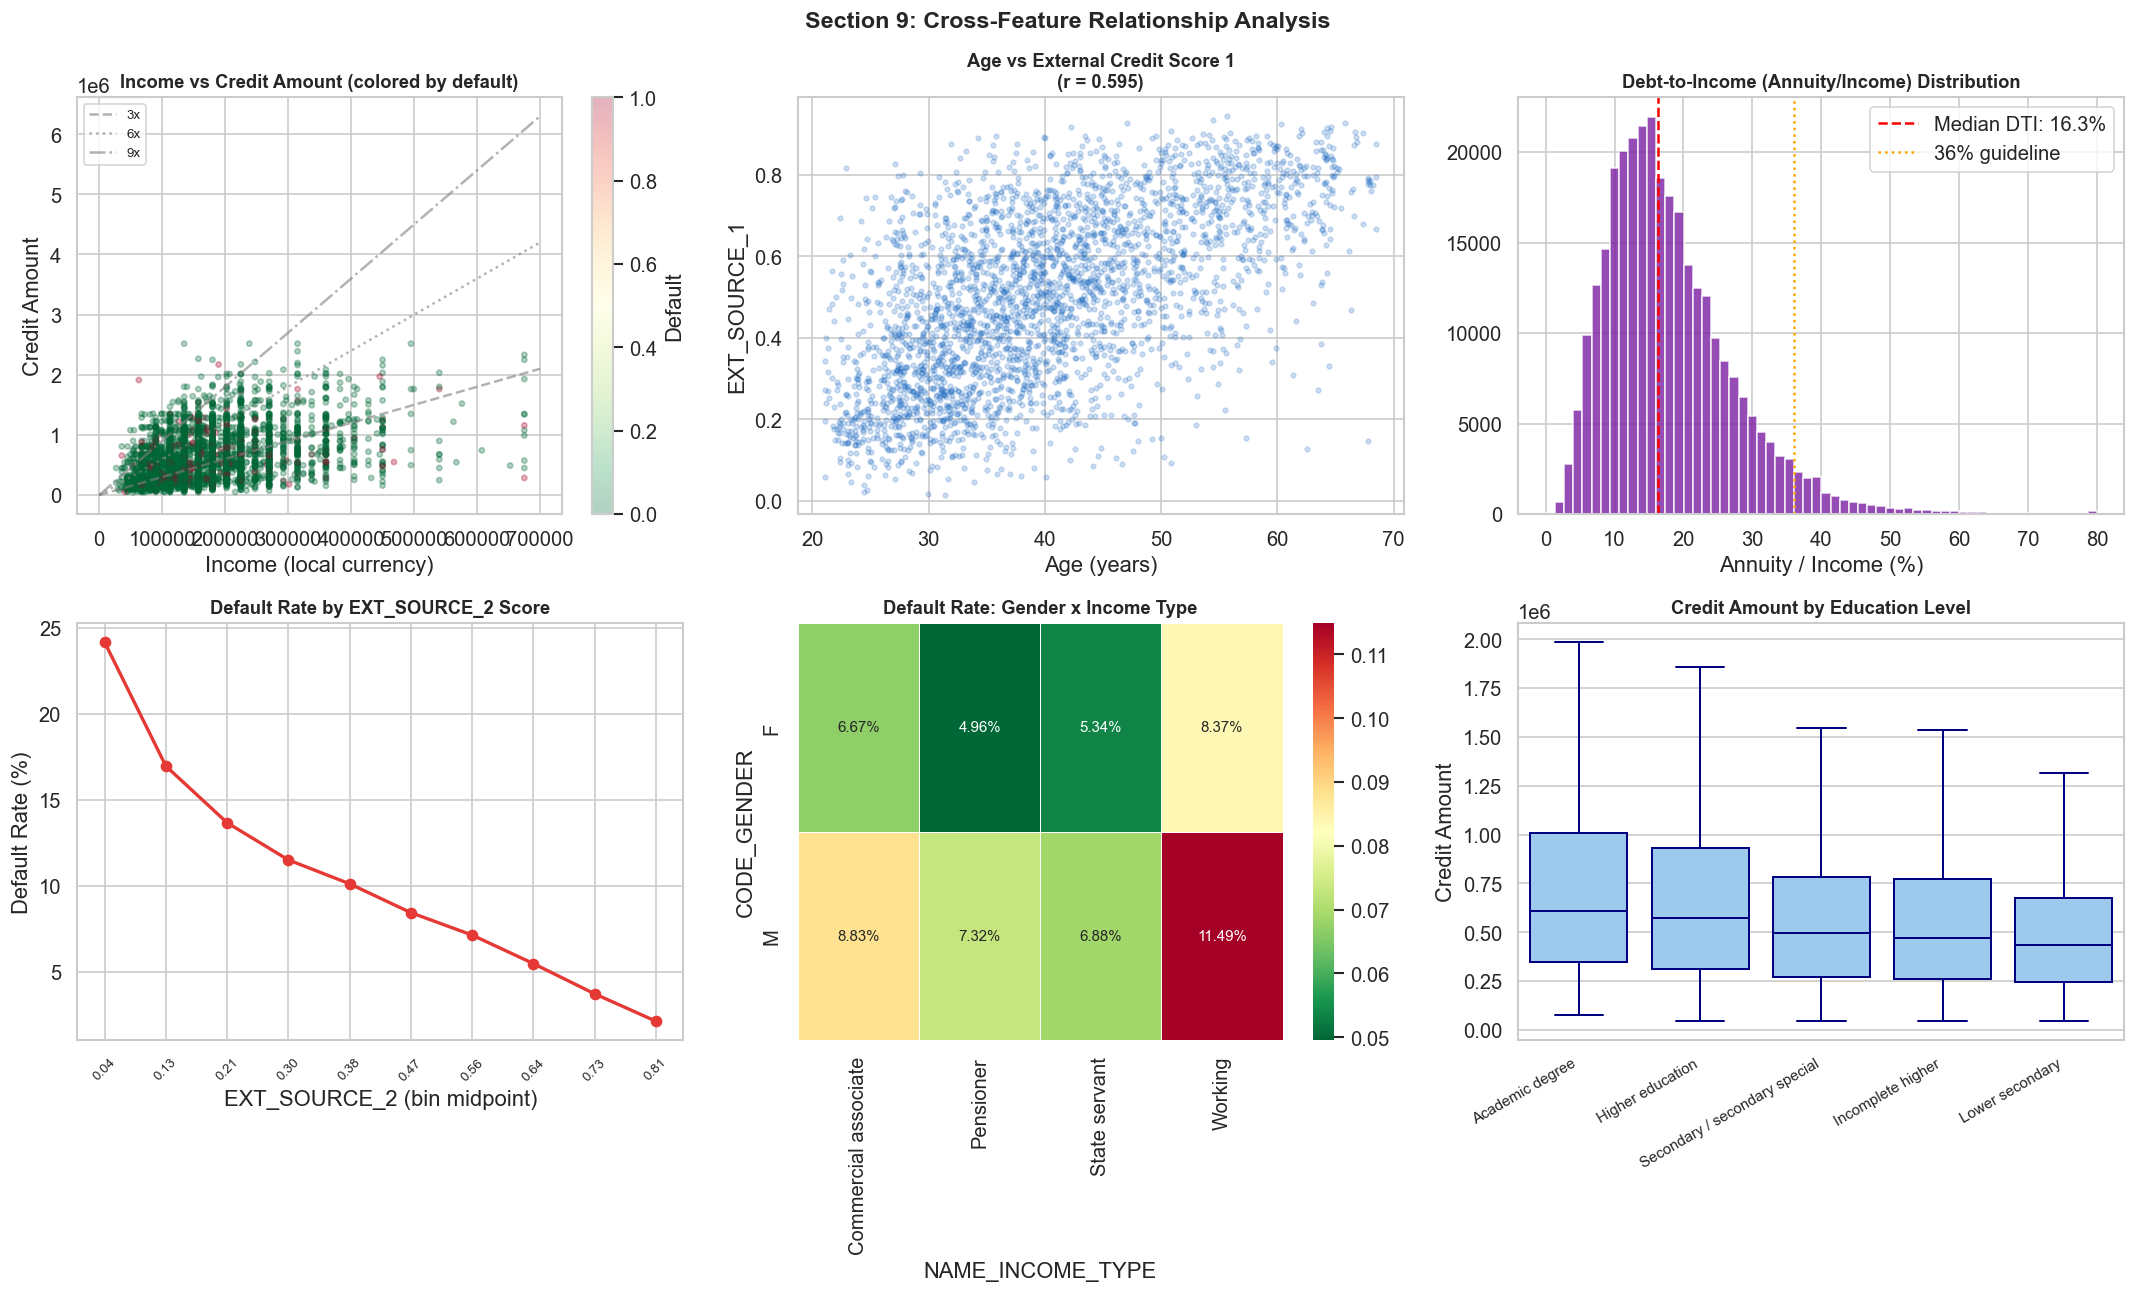

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Income vs Credit Amount
ax = axes[0, 0]
sample = app[app['AMT_INCOME_TOTAL'] < 700000].sample(5000, random_state=42)
scatter = ax.scatter(sample['AMT_INCOME_TOTAL'], sample['AMT_CREDIT'],
                     c=sample['TARGET'], cmap='RdYlGn_r', alpha=0.3, s=10)
ax.set_xlabel('Income (local currency)')
ax.set_ylabel('Credit Amount')
ax.set_title('Income vs Credit Amount (colored by default)', fontsize=11, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Default')
x_r = np.linspace(0, 700000, 100)
for ratio, ls in [(3,'--'), (6,':'), (9,'-.')]: ax.plot(x_r, x_r*ratio, ls, color='gray', alpha=0.6, label=f'{ratio}x')
ax.legend(fontsize=8)

# 2. Age vs EXT_SOURCE_1
ax = axes[0, 1]
s2 = app[['DAYS_BIRTH','EXT_SOURCE_1']].dropna().sample(3000, random_state=42)
s2 = s2.copy()
s2['age'] = s2['DAYS_BIRTH'].abs() / 365.25
ax.scatter(s2['age'], s2['EXT_SOURCE_1'], alpha=0.2, s=8, color='#1565C0')
r = s2[['age','EXT_SOURCE_1']].corr().iloc[0,1]
ax.set_xlabel('Age (years)')
ax.set_ylabel('EXT_SOURCE_1')
ax.set_title(f'Age vs External Credit Score 1\n(r = {r:.3f})', fontsize=11, fontweight='bold')

# 3. DTI distribution
ax = axes[0, 2]
dti = (app['AMT_ANNUITY'] / app['AMT_INCOME_TOTAL'] * 100).clip(upper=80)
ax.hist(dti, bins=60, color='#7B1FA2', alpha=0.8, edgecolor='white')
ax.axvline(dti.median(), color='red', linestyle='--', label=f'Median DTI: {dti.median():.1f}%')
ax.axvline(36, color='orange', linestyle=':', label='36% guideline')
ax.set_xlabel('Annuity / Income (%)')
ax.set_title('Debt-to-Income (Annuity/Income) Distribution', fontsize=11, fontweight='bold')
ax.legend()

# 4. Default rate by EXT_SOURCE_2 bin
ax = axes[1, 0]
app_tmp = app.copy()
app_tmp['ext2_bin'] = pd.cut(app['EXT_SOURCE_2'].dropna(), bins=10)
ext2_def = app_tmp.dropna(subset=['EXT_SOURCE_2']).groupby('ext2_bin', observed=True)['TARGET'].mean()
ax.plot(range(len(ext2_def)), ext2_def.values*100, marker='o', color='#E53935', linewidth=2)
ax.set_xticks(range(len(ext2_def)))
ax.set_xticklabels([f'{i.mid:.2f}' for i in ext2_def.index], rotation=45, fontsize=8)
ax.set_xlabel('EXT_SOURCE_2 (bin midpoint)')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate by EXT_SOURCE_2 Score', fontsize=11, fontweight='bold')

# 5. Gender x Income Type default heatmap
ax = axes[1, 1]
pivot = app[app['CODE_GENDER'] != 'XNA'].groupby(['CODE_GENDER','NAME_INCOME_TYPE'])['TARGET'].mean().unstack()
valid_inc = app['NAME_INCOME_TYPE'].value_counts()
pivot = pivot[[c for c in pivot.columns if valid_inc.get(c, 0) > 100]]
sns.heatmap(pivot, annot=True, fmt='.2%', cmap='RdYlGn_r', ax=ax, linewidths=0.5, annot_kws={'size':9})
ax.set_title('Default Rate: Gender x Income Type', fontsize=11, fontweight='bold')

# 6. Credit amount by education
ax = axes[1, 2]
edu_order = app.groupby('NAME_EDUCATION_TYPE')['AMT_CREDIT'].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=app, x='NAME_EDUCATION_TYPE', y='AMT_CREDIT',
            order=edu_order, ax=ax, showfliers=False,
            color='#90CAF9', linecolor='navy', linewidth=1.2)
ax.set_xlabel('')
ax.set_ylabel('Credit Amount')
ax.set_title('Credit Amount by Education Level', fontsize=11, fontweight='bold')
ax.set_xticklabels(edu_order, rotation=30, ha='right', fontsize=9)
plt.suptitle('Section 9: Cross-Feature Relationship Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
print('=== Credit-to-Income Ratio ===')
cti = app['AMT_CREDIT'] / app['AMT_INCOME_TOTAL']
print(f'Median: {cti.median():.2f}x')
print(f'p75   : {cti.quantile(0.75):.2f}x')
print(f'p95   : {cti.quantile(0.95):.2f}x')
print(f'>6x   : {(cti>6).sum():,} ({(cti>6).mean()*100:.1f}%)')

print('\n=== Age vs EXT_SOURCE correlations ===')
app['age_years'] = app['DAYS_BIRTH'].abs() / 365.25
for src in ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']:
    r = app[['age_years',src]].dropna().corr().iloc[0,1]
    print(f'  Age vs {src}: r = {r:.3f}')

print('\n=== Debt-to-Income (Annuity/Income) ===')
dti2 = app['AMT_ANNUITY'] / app['AMT_INCOME_TOTAL']
print(f'Median DTI: {dti2.median()*100:.1f}%')
print(f'p75 DTI   : {dti2.quantile(0.75)*100:.1f}%')
print(f'p95 DTI   : {dti2.quantile(0.95)*100:.1f}%')
print(f'DTI > 50% : {(dti2>0.5).sum():,} ({(dti2>0.5).mean()*100:.2f}%)')

print('\n=== AMT_CREDIT median by education ===')
print(app.groupby('NAME_EDUCATION_TYPE')['AMT_CREDIT'].median().sort_values(ascending=False).to_string())

=== Credit-to-Income Ratio ===
Median: 3.27x
p75   : 5.16x
p95   : 9.16x
>6x   : 54,725 (17.8%)

=== Age vs EXT_SOURCE correlations ===
  Age vs EXT_SOURCE_1: r = 0.601
  Age vs EXT_SOURCE_2: r = 0.092
  Age vs EXT_SOURCE_3: r = 0.205

=== Debt-to-Income (Annuity/Income) ===
Median DTI: 16.3%
p75 DTI   : 22.9%
p95 DTI   : 35.5%
DTI > 50% : 2,530 (0.82%)

=== AMT_CREDIT median by education ===
NAME_EDUCATION_TYPE
Academic degree                 610,056.0000
Higher education                572,076.0000
Secondary / secondary special   497,520.0000
Incomplete higher               468,648.0000
Lower secondary                 432,949.5000


### What we found

**1. Income versus credit amount: people routinely borrow several times their income.** The median credit-to-income ratio is 3.27x, so a typical applicant asks for more than three years of income. The p95 is 9.16x, and 9,844 applicants (3.2%) ask for more than 10x. Some of that is just how loans work (you repay over years), but the far tail hints at over-requesting or overstated income. There is no strong straight-line link between income and loan size, which means people across the income range ask for similar absolute amounts, and that alone will separate clusters cleanly: a high earner with a small loan and a low earner with the same loan have very different debt burdens.

**2. Age versus External Score 1: a strong positive link (r = 0.601).** This is the strongest cross-feature relationship we found, and it makes sense: the score reflects accumulated repayment history, and older people have had longer to build it. `EXT_SOURCE_2` and `EXT_SOURCE_3` track age far more weakly (r = 0.09 and 0.21), so they seem to measure behaviour less tied to history length. Both age and `EXT_SOURCE_1` stay, since they capture different aspects of credit quality.

**3. Debt-to-income: this population is only modestly leveraged.** The median annuity-to-income ratio is 16.3%, well under the 36% rule of thumb in consumer finance. The p95 is 35.5%, and only 2,530 applicants (0.8%) exceed 50%. A population that is not over-stretched is part of why the overall default rate stays around 8.1%.

**4. EXT_SOURCE_2 versus default: a clean downhill relationship.** Default falls steadily as the score rises, and the decline looks non-linear, dropping sharply at the higher end. Whatever transform we apply should preserve that monotonic shape.

**5. Gender and income type interact.** Men default more across every income type, but the gap is wider for working applicants (men ~11%, women ~7%) than for pensioners (both ~5 to 6%). So the gender effect is partly carried by employment type and income stability rather than gender alone.

**6. Education versus loan size: a clear socioeconomic gradient.** Academic-degree holders take the largest loans (median ~currency units 610K), sliding down to Lower secondary (~currency units 433K), a 41% spread. Education works as a proxy for borrowing capacity, and because it moves as a gradient it is exactly the kind of variable that should be encoded as an ordered scale and will separate clusters well.

---
## Section 10: Summary and the handoff to preprocessing

### What this section does

This is the formal bridge from understanding (Step 1) to action (Step 2). Every finding above is mapped to one concrete preprocessing decision, so the pipeline executes what is written here and nothing it does should be a surprise.

---

## Key findings and what they imply

### Issues that must be fixed first

1. **The `DAYS_EMPLOYED` sentinel (365,243)** touches 18.0% of rows. It has to be flagged and separated before any numeric treatment, because feeding a 1,000-year tenure into a distance calculation corrupts it.
2. **Extreme `AMT_INCOME_TOTAL` values:** one record at currency units 117M and ~250 above currency units 1M would dominate distances uncapped, so a log transform (after a p99 cap) is mandatory.
3. **Housing triplication:** 47 `_AVG`/`_MODE`/`_MEDI` columns correlate at r ~ 0.99; keeping all three triple-weights building attributes.
4. **`CODE_GENDER = 'XNA'`:** 4 invalid records, treated as missing.
5. **Rare income types** (Unemployed, Student, Businessman, Maternity leave; 55 rows total) are too few to stand alone and would create unstable fragments.

### Issues that need careful handling

6. **`EXT_SOURCE_1` missing at 56.4%:** the strongest single predictor is absent for over half the data; a missingness flag preserves the "thin credit file" signal.
7. **Housing block missing at 47 to 70%:** mostly structural (non-apartment housing); one flag is enough.
8. **`OCCUPATION_TYPE` missing at 31.4%:** a genuine collection gap, not a structural absence like `OWN_CAR_AGE`.
9. **`ORGANIZATION_TYPE = 'XNA'` at 18.0%:** the pensioner/unemployed group again, handled consistently with `DAYS_EMPLOYED`.
10. **`DAYS_BIRTH` negative encoding:** converted to positive years.

### Patterns we keep and interpret

11. **EXT_SOURCE_1/2/3 are independent** (r < 0.22); all three stay.
12. **Age and EXT_SOURCE_1 co-vary** (r = 0.60); both stay, they describe different things.
13. **No bureau record** is itself a signal for 1,700 thin-file applicants; `FLAG_NO_BUREAU` captures it.
14. **Social-circle defaults** mark a behavioural sub-population (11.4%), not noise.
15. **Installment lateness** (8.4%), aggregated per applicant, is a powerful behavioural feature.

---

## A note on encoding for clustering

The justification table below prescribes how each variable is cleaned and grouped. One choice deserves its own paragraph because it shapes the whole feature space: how categorical variables are turned into numbers for a distance-based algorithm.

We deliberately avoid one-hot encoding for the nominal variables. On Euclidean distance, one-hot does two damaging things: it inflates the dimension count with sparse binary columns that together outweigh genuine continuous features, and it forces every category to be equidistant from every other. So we encode each categorical to match what it actually is:

- **`NAME_EDUCATION_TYPE` to ordinal 0-4.** Education is a ladder (Section 9 shows a clean gradient against loan size), so one ordered integer is both truthful and compact.
- **`DEF_30_CNT_SOCIAL_CIRCLE` to ordinal 0 / 1 / 2+.** The order is real and meaningful.
- **`NAME_INCOME_TYPE` and `ORGANIZATION_TYPE` to frequency encoding.** These are nominal with no order, so each becomes a single "how common is this category" axis instead of a dozen sparse dummies. Pensioners remain separately flagged via `FLAG_SENTINEL_EMPLOYED`.

This keeps the clustering feature space compact and interpretable, and it removes a perfect-collinearity trap (sentinel = `ORGANIZATION_TYPE_Unknown` = `NAME_INCOME_TYPE_Pensioner`, r ~ 1.0) that one-hot encoding produced in an earlier run.

---

## Preprocessing justification table

| Finding | Columns | Severity | Action in Step 2 | Why |
|---|---|---|---|---|
| `DAYS_EMPLOYED` sentinel (365,243) | `DAYS_EMPLOYED`, `ORGANIZATION_TYPE` | High | Flag with `FLAG_SENTINEL_EMPLOYED`; set 365,243 to NaN; handle `ORGANIZATION_TYPE='XNA'` | Sentinel wrecks distributions; 18% of data; 5.4% vs 8.7% default confirms a real state |
| Extreme income | `AMT_INCOME_TOTAL` | High | Winsorize at p99 (currency units 472,500), then log | Max is 247x the median; one record would dominate distances |
| Housing triplication | all `_AVG`/`_MEDI` (31 cols) | High | Drop `_AVG` and `_MEDI`, keep `_MODE` | r > 0.99; keeping all three triples building weight |
| `DAYS_BIRTH` encoding | `DAYS_BIRTH` | High | Convert to `abs/365.25` years | Negative values are meaningless in distance |
| `CODE_GENDER='XNA'` | `CODE_GENDER` | Medium | Treat as missing | 4 records, likely entry error |
| Rare income types | `NAME_INCOME_TYPE` | Medium | Group into `Other_Rare` | 55 rows total; cannot form stable segments |
| `EXT_SOURCE_1` missingness | `EXT_SOURCE_1` | High | Flag, then median-impute | 56% missing; the blank is a thin-file risk signal |
| `OWN_CAR_AGE` missingness | `OWN_CAR_AGE` | High | Create `FLAG_NO_CAR`; impute 0 | Blank means no car; the flag is more informative than a filled age |
| `OCCUPATION_TYPE` missingness | `OCCUPATION_TYPE` | Medium | Group-mode impute by income type | 31% missing, genuine gap |
| `ORGANIZATION_TYPE` cardinality | `ORGANIZATION_TYPE` | Medium | Collapse 58 to ~12 macro-sectors, then frequency-encode | 58 is too granular; macro-sectors keep the signal as one axis |
| Education encoding | `NAME_EDUCATION_TYPE` | Medium | Ordinal 0-4 | Real order; ordinal beats one-hot for clustering |
| Housing block missingness | 47 housing cols | Medium | One `FLAG_NO_HOUSING_DATA`; impute 0 | ~50% structurally absent; one flag suffices |
| Correlated pairs (89, r>0.85) | `OBS_30`/`OBS_60`, `FLAG_EMP_PHONE`/`DAYS_EMPLOYED`, etc. | Medium | Drop the redundant partner | Redundancy inflates effective dimensionality |
| Social-circle pseudo-outliers | `DEF_30/60_CNT_SOCIAL_CIRCLE` | Low | Bin 0/1/2+, do not winsorize | The 11.4% are a real sub-population, not noise |
| `CNT_CHILDREN` > 10 | `CNT_CHILDREN`, `CNT_FAM_MEMBERS` | Low | Cap at 10 | 19 is implausible; cap beats deletion |
| `TARGET` label | `TARGET` | High | Drop from every mining feature matrix | Unsupervised methods must not see the label |
| Amount skewness | `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE` | Medium | Log transform | Skewness 1.2 to 1.6; log helps distance behave |
| Bureau absence | applicants not in `bureau` | Medium | Create `FLAG_NO_BUREAU` | 1,700 thin-file applicants; absence is a feature |
| Installment DPD | `installments_payments` | Medium | Per-applicant mean/max DPD, % late, % severe (>30d) | 8.4% late; behavioural aggregates beat snapshot attributes |
| Card utilization | `credit_card_balance` | Medium | Per-applicant mean/max utilization, months of history | Utilization >80% is a classic stress signal |

---

*This table is the handoff to Step 2. The pipeline runs exactly what is prescribed here.*

---
## Section 11: Decision-useful portfolio view

The dashboard needs a compact visual summary, while the notebook keeps the
reasoning. Financial amounts are shown in the dataset's anonymised currency
units; the source does not establish a currency. Missingness is separated
into structural absence, score uncertainty, and source-data quality because
those states require different actions. Gender is retained only for
descriptive fairness monitoring and is excluded from clustering and the
cluster-risk backtest.


In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
phase1_out = PROJECT_ROOT / 'results/phase1_preprocessing'
phase1_out.mkdir(parents=True, exist_ok=True)

combined_app = pd.concat([
    app.assign(SOURCE_SPLIT='train'),
    pd.read_csv(DATA + 'application_test.csv').assign(SOURCE_SPLIT='test'),
], ignore_index=True, sort=False)

quality_rows = [
    {
        'issue': 'Employment sentinel',
        'affected_rows': int((combined_app['DAYS_EMPLOYED'] == 365243).sum()),
        'affected_share': float((combined_app['DAYS_EMPLOYED'] == 365243).mean()),
        'business_meaning': 'Pensioner or non-employed status marker, not 1,000 years of work',
        'treatment': 'Replace with missing duration and retain a sentinel flag',
    },
    {
        'issue': 'EXT_SOURCE_1 unavailable',
        'affected_rows': int(combined_app['EXT_SOURCE_1'].isna().sum()),
        'affected_share': float(combined_app['EXT_SOURCE_1'].isna().mean()),
        'business_meaning': 'Score uncertainty or thin information; not adverse behaviour',
        'treatment': 'Median imputation plus an explicit missing-score flag',
    },
    {
        'issue': 'No car-age value',
        'affected_rows': int(combined_app['OWN_CAR_AGE'].isna().sum()),
        'affected_share': float(combined_app['OWN_CAR_AGE'].isna().mean()),
        'business_meaning': 'Usually structural absence because the applicant has no car',
        'treatment': 'Set age to zero and retain a no-car indicator',
    },
    {
        'issue': 'Housing detail unavailable',
        'affected_rows': int(combined_app['TOTALAREA_MODE'].isna().sum()),
        'affected_share': float(combined_app['TOTALAREA_MODE'].isna().mean()),
        'business_meaning': 'Property record not available; not proof of poor credit quality',
        'treatment': 'Structural zero plus one no-housing-data indicator',
    },
    {
        'issue': 'Extreme income above p99',
        'affected_rows': int((combined_app['AMT_INCOME_TOTAL'] > combined_app['AMT_INCOME_TOTAL'].quantile(.99)).sum()),
        'affected_share': float((combined_app['AMT_INCOME_TOTAL'] > combined_app['AMT_INCOME_TOTAL'].quantile(.99)).mean()),
        'business_meaning': 'Rare amount that can dominate Euclidean distance; not automatically an error',
        'treatment': 'Cap the clustering value at p99; preserve the rule and audit trail',
    },
]
quality = pd.DataFrame(quality_rows).sort_values('affected_share', ascending=True)
quality.to_csv(phase1_out / 'data_quality_summary.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(quality['issue'], quality['affected_share'] * 100, color='#4E6E8A')
for bar, value in zip(bars, quality['affected_share'] * 100):
    ax.text(value + .6, bar.get_y() + bar.get_height()/2, f'{value:.1f}%', va='center')
ax.set_xlabel('Share of combined train + test applications')
ax.set_title('Data conditions require different treatments', fontweight='bold')
ax.set_xlim(0, max(quality['affected_share'] * 100) * 1.18)
plt.tight_layout()
plt.savefig(phase1_out / 'plot_data_quality.png', dpi=160, bbox_inches='tight')
plt.show()

train_default = app['TARGET'].mean()
portfolio_context = pd.DataFrame([
    ('Combined applications', len(combined_app), 'Train + test used for unsupervised pattern discovery'),
    ('Labeled train applications', len(app), 'Only these rows may enter TARGET evaluation'),
    ('Unlabeled test applications', (combined_app['SOURCE_SPLIT'] == 'test').sum(), 'Excluded from precision and recall'),
    ('Observed train default rate', train_default, 'Payment-difficulty label prevalence; not a population PD'),
], columns=['measure', 'value', 'business_interpretation'])
portfolio_context.to_csv(phase1_out / 'portfolio_context.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
split_counts = combined_app['SOURCE_SPLIT'].value_counts().reindex(['train', 'test'])
axes[0].bar(['Labeled train', 'Unlabeled test'], split_counts.values, color=['#34506B', '#9FB6C6'])
axes[0].set_title('Discovery pool and evaluation boundary', fontweight='bold')
axes[0].set_ylabel('Applications')
for i, v in enumerate(split_counts.values):
    axes[0].text(i, v + len(combined_app)*.01, f'{v:,}', ha='center')
target_counts = app['TARGET'].value_counts().reindex([0, 1])
axes[1].bar(['No observed default', 'Observed default'], target_counts.values,
            color=['#5B8A72', '#B4504A'])
axes[1].set_title(f'Train label is imbalanced ({train_default:.1%} default)', fontweight='bold')
for i, v in enumerate(target_counts.values):
    axes[1].text(i, v + len(app)*.01, f'{v:,}', ha='center')
plt.tight_layout()
plt.savefig(phase1_out / 'plot_evaluation_boundary.png', dpi=160, bbox_inches='tight')
plt.show()


---
## Preprocessing contract: source evidence versus mining geometry

Broad portfolio segments and record investigations need different versions
of extreme values. The clustering matrix bounds continuous distance axes at
the 0.5th and 99.5th percentiles so a few extreme histories do not consume a
K-Means centroid. The business artifact separately retains `SOURCE_*` values
and external-score missingness flags, so a reviewer sees the supplied value
or true absence rather than a cap or imputation. `TARGET` is used only in the
train-ID mutual-information screen and later outcome diagnostics; it never
determines the unsupervised features or clusters.


In [ ]:
clip_audit = pd.read_csv(phase1_out / 'clustering_clip_limits.csv')
clip_audit['total_rows_bounded'] = clip_audit['rows_clipped_low'] + clip_audit['rows_clipped_high']
plot_clip = clip_audit.nlargest(12, 'total_rows_bounded').sort_values('total_rows_bounded')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_clip['feature'], plot_clip['total_rows_bounded'], color='#6E7493')
ax.set_xlabel('Rows bounded for segmentation distance only')
ax.set_title('Robust distance treatment preserves source evidence', fontweight='bold')
plt.tight_layout(); plt.savefig(phase1_out / 'plot_clustering_clip_audit.png', dpi=160, bbox_inches='tight'); plt.show()

business_contract = pd.read_csv(
    PROJECT_ROOT / 'datasets/final/features_business.csv', nrows=5)
source_cols = [c for c in business_contract.columns if c.startswith('SOURCE_')]
score_flags = [c for c in business_contract.columns if c.startswith('FLAG_EXT_SOURCE_')]
print('Preserved source columns:', source_cols)
print('External-score availability flags:', score_flags)
